# Data Analysis

## Preparations

First of all, we read the raw results.

In [107]:
import pandas as pd

import os

from pathlib import Path


ROOT = Path(os.getcwd())


def data_dir(root: Path) -> Path:
    return root / "data"


# for the export of tables and plots
def output(root: Path) -> Path:
    return data_dir(root) / "output"


def raw_results(root: Path) -> Path:
    return data_dir(root) / "raw_results" / "raw_results.csv"


# for the export of LaTeX tables:
def latex_tables(root: Path) -> Path:
    return output(root) / "latex_tables"


# for the export of figures:
def figures(root: Path) -> Path:
    return output(root) / "figures"


rr = pd.read_csv(
    raw_results(ROOT),
    low_memory=False,
)

Then, we drop columns that are actually not usable.

In [2]:
COLS_OF_INTEREST = [
    "full_name_of_repo",
    "commit_sha",
    "path",
    "is_ccdc_event",
    "detected_channel",
    "created_at",
    "pushed_at",
    "updated_at",
    "date",
]

UNNECESSARY_COLS = []

for col in rr.columns:
    if col not in COLS_OF_INTEREST:
        UNNECESSARY_COLS.append(col)

rr.drop(columns=UNNECESSARY_COLS, inplace=True)

Next, we perform data conversion.

In [3]:
def to_bool(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series
    s = series.astype("string").str.strip().str.lower()
    mapping = {"true": True, "false": False}
    return s.map(mapping)


rr["is_ccdc_event"] = to_bool(rr["is_ccdc_event"])

rr["detected_channel"] = rr["detected_channel"].astype("string").fillna("")

DATETIME_COLS = ["created_at", "pushed_at", "updated_at", "date"]

for col in DATETIME_COLS:
    if col in rr.columns:
        rr[col] = pd.to_datetime(rr[col], errors="coerce", utc=True)


At this point, our results look like this:

In [4]:
rr.head()

,full_name_of_repo,commit_sha,path,is_ccdc_event,detected_channel,created_at,pushed_at,updated_at,date
0,sendbird/SendBird-SDK-JavaScript,70cbf5f0058fc7d0f41315906dbb37a15c8fa308,README.md,True,,2016-02-15 04:10:04+00:00,2023-08-24 06:16:42+00:00,2025-07-17 16:49:13+00:00,2020-12-21 08:46:06+00:00
1,userfrosting/UserFrosting,fbd035113ec7f500586fb874b6daef4938394d0b,README.txt,False,,2014-03-26 18:05:59+00:00,2026-01-13 01:08:29+00:00,2025-12-22 14:31:34+00:00,2014-03-26 18:03:09+00:00
2,ROCm/MIOpen,fa92f715406692a950ec8ddf5a5bc7b712f686d9,README.md,False,,2017-06-27 17:51:22+00:00,2026-01-09 19:20:15+00:00,2025-12-31 12:44:13+00:00,2017-04-05 16:18:31+00:00
3,graphql-python/graphql-core,82d54e7a87c1debd1ad46aa3d5e5631a1ea5c37d,README.md,False,facebook,2018-08-01 20:57:07+00:00,2026-01-11 15:19:04+00:00,2026-01-11 15:19:08+00:00,2022-09-22 17:13:24+00:00
4,kaliop-uk/ezmigrationbundle,58280f1c6a22a6fe26c36f488149d2701639a5b1,README.md,False,,2015-10-17 13:45:41+00:00,2023-06-16 08:53:29+00:00,2025-10-15 16:14:10+00:00,2016-08-08 12:04:46+00:00


From here on, we work with a new Python variable/identifier.

In [5]:
results = rr.copy()

Now, we remove the channels detected for the subjects that are **not** CCDC events.

In [6]:
results["detected_channel"] = (
    results["detected_channel"]
        .where(results["is_ccdc_event"] == True, "")
)

Next, we transform the data frame: each row should be a unique subject – one row per subject.

In [7]:
KEY_COLS = [
    "full_name_of_repo",
    "commit_sha",
    "path",
]

gb = results.groupby(KEY_COLS, dropna=False)


def agg_channels(x: pd.Series) -> tuple[str, ...]:
    vals = [
        v
        for v in x.astype("string").tolist()
        if isinstance(v, str) and v.strip() != ""
    ]
    return tuple(sorted(set(vals)))


agg = gb.agg(
    is_ccdc_event=("is_ccdc_event", "first"),
    detected_channels=("detected_channel", agg_channels),
)

for col in COLS_OF_INTEREST:
    if col not in KEY_COLS and col not in agg.columns and col != "detected_channel":
        agg[col] = gb[col].first()

results = agg.reset_index()

At this point, we start extracting further information based on the metadata already present in the data frame.

We define the first activity of a repository to be the first point in time providing evidence for project activity: either the time the repository was created on GitHub or the time of the first commit.

In [8]:
results["first_activity"] = (
    results[["date", "created_at"]]
        .min(axis=1)
        .groupby(results["full_name_of_repo"], dropna=False)
        .transform("min")
)

The repository age is the simply the time passed since the repository's first activity.

In [9]:
import numpy as np

results["repo_age"] = (
    (results["date"] - results["first_activity"]).to_numpy()
    / np.timedelta64(1, "D")
)

results.sort_values(["full_name_of_repo", "repo_age"], inplace=True)
results.reset_index(drop=True, inplace=True)

Based on the age of the repository at the time of a commit, we can assign the subjects to a set of age groups.

In [10]:
AGE_GROUPS = [
    (0, 1, "0-1"),
    (1, 2, "1-2"),
    (2, 3, "2-3"),
    (3, 4, "3-4"),
    (4, 5, "4-5"),
    (5, 6, "5-6"),
    (6, 7, "6-7"),
    (7, 8, "7-8"),
    (8, 9, "8-9"),
    (9, 10, "9-10"),
    (10, 11, "10-11"),
    (11, 12, "11-12"),
    (12, 13, "12-13"),
    (13, 14, "13-14"),
    (14, 15, "14-15"),
    (15, 999, "15+"),
]


def assign_age_group(age_in_days: float) -> int | None:
    if pd.isna(age_in_days):
        return None
    for lo, hi, label in AGE_GROUPS:
        if lo * 365.25 <= age_in_days < hi * 365.25:
            return lo
    return None


results["age_group"] = results["repo_age"].apply(assign_age_group)

Later, we will group subjects by the year of their commits. Out of convenience, we introduce an extra column for that.

In [11]:
results["year"] = results["date"].dt.year

Now, we create a dedicated data frame for the repository demographics.

In [12]:
repos = (
    results
        .groupby("full_name_of_repo", as_index=False)
        .agg(
            created_at=("created_at", "first"),
            pushed_at=("pushed_at", "first"),
            updated_at=("updated_at", "first"),
            first_activity=("first_activity", "first"),
            first_subject_at=("date", "min"),
            last_subject_at=("date", "max"),
        )
)

This allows us to remove repository metadata from the results data frame.

In [13]:
results.drop(
    columns=["created_at", "pushed_at", "updated_at", "first_activity"],
    inplace=True,
)

Since we introduced *first_activity*, consequently we introduce *last_activity*: the timestamp that is more recent, *pushed_at* or *updated_at*.

In [14]:
repos["last_activity"] = repos[["pushed_at", "updated_at"]].max(axis=1)

Then we create columns for the age (in days), the age group, and the age group at the time of a repository's first subject.

In [15]:

repos["age"] = (
    (repos["last_activity"] - repos["first_activity"]).to_numpy()
    / np.timedelta64(1, "D")
)

repos["age_group"] = repos["age"].apply(assign_age_group)

repos["days_until_first_subject"] = (
    (repos["first_subject_at"] - repos["first_activity"]).to_numpy()
    / np.timedelta64(1, "D")
)
repos["age_group_at_first_subject"] = repos["days_until_first_subject"].apply(assign_age_group)

repos.drop(columns=["days_until_first_subject"], inplace=True)
repos.sort_values("full_name_of_repo", ascending=False, inplace=True)
repos.reset_index(drop=True, inplace=True)

Our repository data frame looks like this:

In [16]:
repos.head()

,full_name_of_repo,created_at,pushed_at,updated_at,first_activity,first_subject_at,last_subject_at,last_activity,age,age_group,age_group_at_first_subject
0,zimmski/go-mutesting,2014-12-26 22:23:44+00:00,2024-07-04 16:42:16+00:00,2026-01-07 10:55:25+00:00,2014-12-26 22:23:44+00:00,2014-12-26 22:27:21+00:00,2018-11-01 08:51:39+00:00,2026-01-07 10:55:25+00:00,4029.522002,11,0
1,zenhack/haskell-capnp,2016-05-15 17:11:49+00:00,2023-06-24 03:32:45+00:00,2025-08-26 00:33:29+00:00,2016-05-10 14:32:29+00:00,2016-05-10 14:32:29+00:00,2023-02-08 22:18:46+00:00,2025-08-26 00:33:29+00:00,3394.417361,9,0
2,zendesk/sunshine-conversations-web,2015-06-01 17:03:32+00:00,2025-12-15 16:34:58+00:00,2025-12-15 16:35:01+00:00,2015-06-01 17:03:32+00:00,2017-10-06 17:18:00+00:00,2025-06-30 11:42:09+00:00,2025-12-15 16:35:01+00:00,3849.980197,10,2
3,zdavatz/oddb.org,2012-12-06 18:37:02+00:00,2026-01-12 18:04:13+00:00,2026-01-12 18:04:17+00:00,2010-12-21 08:34:07+00:00,2010-12-21 08:34:07+00:00,2025-08-24 06:04:18+00:00,2026-01-12 18:04:17+00:00,5501.395949,15,0
4,yola/yolapy,2015-08-27 16:19:04+00:00,2020-04-30 08:58:42+00:00,2020-04-30 08:58:08+00:00,2015-08-26 10:43:31+00:00,2015-08-26 10:43:31+00:00,2015-09-02 18:33:56+00:00,2020-04-30 08:58:42+00:00,1708.927211,4,0


The base sample of repositories is from June 2019. Hence, we remove any subjects originating from repositories that were added to GitHub after June 2019.

In [17]:
repos = repos.set_index("full_name_of_repo")
results = results.set_index("full_name_of_repo")

mask = repos["created_at"] >= "2019-07-01"

repos = repos.loc[~mask]
results = results.loc[results.index.isin(repos.index)]
repos.reset_index(inplace=True)
results.reset_index(inplace=True)

We make the path values case insensitive to only analyze how README and CONTRIBUTING files are distributed over time independent of a project maintainers opinion on whether or not a README/CONTRIBUTING file should be named in ALL CAPS.

In [18]:
results["path"] = (
    results["path"]
    .str.split(".", n=1)
    .apply(lambda x: x[0].upper() + ("." + x[1] if len(x) > 1 else ""))
)

Since I do not know whether and how there are differences between CONTRIBUTING files and README files regarding what project maintainers decide to document, I decided to define a dedicated data frame for README files only. This allows for a more nuanced analysis later.

**However, originally I had included CONTRIBUTING files arguing that more and more projects these days point to their CONTRIBUTING files for communication channel relevant information. So, it makes sense, to keep the subjects that come from CONTRIBUTING files in the data set of the analysis.**

In [19]:
# readme_results = results[results["path"].str.contains("README", case=False, na=False)]

We split the results/subjects in two: subjects before the base sample was drawn and subjects after June 2019. Why? Because if it was true that projects create CCDC events in their early years, not having any new projects for the time after June 2019 would create a bias in the data. How would we be able to analyze trends over time?

In [20]:
results_before_july_2019 = results[results["date"] < "2019-07-01"]
results_since_july_2019 = results[results["date"] >= "2019-07-01"]

## Setup and Helper Functions

In [21]:
from collections.abc import Callable, Sequence
from dataclasses import dataclass


MetricFn = Callable[[pd.DataFrame], object]


def _require_cols(g: pd.DataFrame, cols: Sequence[str]) -> None:
    missing = [c for c in cols if c not in g.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")


# ---------------------------------------------------------------------
# Metrics
# ---------------------------------------------------------------------
def m_n_subjects(g: pd.DataFrame) -> int:
    return int(len(g))


def m_n_repos(g: pd.DataFrame) -> int:
    _require_cols(g, ["full_name_of_repo"])
    return int(g["full_name_of_repo"].nunique())


def m_n_commits(g: pd.DataFrame) -> int:
    _require_cols(g, ["commit_sha"])
    return int(g["commit_sha"].nunique())


def m_n_distinct_paths(g: pd.DataFrame) -> int:
    _require_cols(g, ["path"])
    return int(g["path"].nunique())


def m_positive_rate(g: pd.DataFrame) -> float:
    _require_cols(g, ["is_ccdc_event"])
    n = len(g)
    return np.nan if n == 0 else float(g["is_ccdc_event"].sum() / n)


def m_n_distinct_channels(g: pd.DataFrame) -> int:
    _require_cols(g, ["detected_channels"])
    return int(
        g["detected_channels"]
        .explode()
        .dropna()
        .nunique()
    )


# ---------------------------------------------------------------------
# Registry: metric_name -> (fn, required_columns)
# ---------------------------------------------------------------------
METRICS: dict[str, tuple[MetricFn, tuple[str, ...]]] = {
    "n_subjects": (m_n_subjects, ()),
    "n_repos": (m_n_repos, ("full_name_of_repo",)),
    "n_commits": (m_n_commits, ("commit_sha",)),
    "n_distinct_paths": (m_n_distinct_paths, ("path",)),
    "positive_rate": (m_positive_rate, ("is_ccdc_event",)),
    "n_distinct_channels": (
        m_n_distinct_channels,
        ("detected_channels",),
    ),
}

ALL_METRICS = (
    "n_subjects",
    "n_repos",
    "n_commits",
    "n_distinct_paths",
    "positive_rate",
    "n_distinct_channels",
)


# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------
@dataclass(frozen=True)
class SummarizeConfig:
    include_metrics: tuple[str, ...]
    group_keys: tuple[str, ...] = ()
    forbid_access_to_group_keys: bool = True
    drop_group_keys_from_frame: bool = True
    deny_columns: tuple[str, ...] = ()


# ---------------------------------------------------------------------
# Core summarization
# ---------------------------------------------------------------------
def summarize_subjects_configurable(
    g: pd.DataFrame,
    cfg: SummarizeConfig,
) -> pd.Series:

    g_eff = (
        g.drop(columns=list(cfg.group_keys), errors="ignore")
        if cfg.drop_group_keys_from_frame and cfg.group_keys
        else g
    )

    forbidden = set(cfg.deny_columns)
    if cfg.forbid_access_to_group_keys:
        forbidden |= set(cfg.group_keys)

    out: dict[str, object] = {}

    for name in cfg.include_metrics:
        if name not in METRICS:
            raise KeyError(
                f"Unknown metric: {name}. "
                f"Known: {sorted(METRICS)}"
            )

        fn, required = METRICS[name]

        illegal = [c for c in required if c in forbidden]
        if illegal:
            raise ValueError(
                f"Metric '{name}' requires forbidden columns {illegal}. "
                f"Forbidden: {sorted(forbidden)}"
            )

        out[name] = fn(g_eff)

    return pd.Series(out)

In [22]:
def distribution_stats(
    s: pd.Series,
    *,
    prefix: str = "",
    dropna: bool = True,
) -> pd.Series:
    """
    Core descriptive stats for a numeric series, including boxplot whiskers/outliers.
    Works for both raw numeric data and 'counts per category' (value_counts output values).
    """
    if dropna:
        s = s.dropna()

    if s.empty:
        return pd.Series(dtype="float64")

    s = pd.to_numeric(s, errors="coerce").dropna()
    if s.empty:
        return pd.Series(dtype="float64")

    q1 = s.quantile(0.25)
    q2 = s.quantile(0.50)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    # Handle iqr=0 robustly (all values equal) without producing empty slices
    if pd.isna(iqr) or iqr == 0:
        lower_whisker = s.min()
        upper_whisker = s.max()
        n_outliers = 0
    else:
        lo = q1 - 1.5 * iqr
        hi = q3 + 1.5 * iqr
        lower_whisker = s[s >= lo].min()
        upper_whisker = s[s <= hi].max()
        n_outliers = int(((s < lower_whisker) | (s > upper_whisker)).sum())

    def k(name: str) -> str:
        return f"{prefix}{name}" if prefix else name

    return pd.Series({
        k("n"): int(len(s)),
        k("min"): float(s.min()),
        k("max"): float(s.max()),
        k("mean"): float(s.mean()),
        k("median"): float(q2),
        k("q1"): float(q1),
        k("q3"): float(q3),
        k("iqr"): float(iqr),
        k("lower_whisker"): float(lower_whisker),
        k("upper_whisker"): float(upper_whisker),
        k("n_outliers"): int(n_outliers),
    })


def boxplot_stats(s: pd.Series) -> pd.Series:
    # Now just a thin wrapper around the shared core
    return distribution_stats(s)


def value_counts_stats(vc: pd.Series) -> pd.Series:
    """
    Stats for a value_counts() result: distribution stats of the counts + concentration metrics.
    Expects vc to be sorted descending (as value_counts() returns by default).
    """
    vc = vc.dropna()
    if vc.empty:
        return pd.Series(dtype="float64")

    total = int(vc.sum())
    n_categories = int(len(vc))

    # shared distribution/boxplot stats over "counts per category"
    core = distribution_stats(vc, prefix="count_")

    # concentration / dominance (requires descending order)
    top_1 = int(vc.iloc[0])
    top_5_sum = int(vc.iloc[:5].sum())
    top_10_sum = int(vc.iloc[:10].sum())

    conc = pd.Series({
        "n_categories": n_categories,
        "total_count": total,
        "top_1_count": top_1,
        "top_1_share": (top_1 / total) if total else float("nan"),
        "top_5_share": (top_5_sum / total) if total else float("nan"),
        "top_10_share": (top_10_sum / total) if total else float("nan"),
    })

    return pd.concat([conc, core])

In [23]:
from collections.abc import Iterable

def col_to_int(df: pd.DataFrame, int_cols: Iterable[str]) -> pd.DataFrame:
    cols = [c for c in int_cols if c in df.columns]
    df[cols] = df[cols].astype("Int64")
    return df


INT_COLS_OF_SUMMARY = [
    "n_subjects",
    "n_repos",
    "n_commits",
    "n_distinct_paths",
    "n_distinct_channels",
]

INT_COLS_OF_VC_STATS = [
    "n_categories",
    "total_count",
    "min_count",
    "max_count",
    "median_count",
    "q1_count",
    "q3_count",
    "iqr_count",
    "top_1_count",
]

In [24]:
def vc_detected_channels(
    g: pd.DataFrame,
    *,
    drop_empty: bool = True,
) -> pd.Series:
    """
    Returns value_counts of channels for one group g.
    Assumes g["detected_channels"] contains iterables/tuples of channels, possibly empty () or NaN.
    """
    col: str = "detected_channels"
    s = g[col]

    # explode expects list-like; NaN stays NaN; () becomes empty -> drops on explode
    exploded = s.explode()

    # Optional cleanup
    exploded = exploded.dropna()
    exploded = exploded.astype("string")

    if drop_empty:
        exploded = exploded[exploded.str.strip() != ""]

    # value_counts -> counts per channel
    vc = exploded.value_counts(dropna=False)

    # Make the result stable/consistent
    vc.index.name = "channel"
    vc.name = "count"
    return vc

In [25]:
import matplotlib as mpl

mpl.rcParams.update({
    # --- text / fonts ---
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,

    # --- lines ---
    "lines.linewidth": 1.2,
    "lines.markersize": 4,

    # --- axes / spines ---
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.linewidth": 0.4,
    "grid.alpha": 0.3,

    # --- figure / export ---
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def set_size(width_mm=85, height_mm=60):
    w = width_mm / 25.4
    h = height_mm / 25.4
    return (w, h)

### Setup: Creating LaTeX ready Figures

In [114]:
# IEEE / LaTeX-ready plotting setup for Jupyter notebooks
# -------------------------------------------------------
# This cell configures Matplotlib (and optionally Seaborn) so that figures
# integrate well into an IEEE paper and can be exported as PDF/PGF/PNG.

from pathlib import Path
import math

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: set this to True only if a LaTeX installation is available
USE_LATEX = False

# IEEE column widths (in pt)
IEEE_SINGLE_COLUMN_PT = 252.0
IEEE_DOUBLE_COLUMN_PT = 516.0

def pt_to_inch(pt: float) -> float:
    return pt / 72.27

def ieee_figsize(
    width: str = "single",
    fraction: float = 1.0,
    ratio: float = (math.sqrt(5) - 1) / 2,
) -> tuple[float, float]:
    """
    Return figure size in inches for IEEE papers.

    Parameters
    ----------
    width : {"single", "double"} or float
        "single"  -> IEEE single-column width
        "double"  -> IEEE double-column width
        float     -> custom width in pt
    fraction : float
        Fraction of the target width to use.
    ratio : float
        Height/width ratio. Default: golden ratio.
    """
    if width == "single":
        width_pt = IEEE_SINGLE_COLUMN_PT
    elif width == "double":
        width_pt = IEEE_DOUBLE_COLUMN_PT
    elif isinstance(width, (int, float)):
        width_pt = float(width)
    else:
        raise ValueError("width must be 'single', 'double', or a numeric pt value.")

    fig_width_in = pt_to_inch(width_pt) * fraction
    fig_height_in = fig_width_in * ratio
    return fig_width_in, fig_height_in

# Global style configuration
sns.set_theme(style="whitegrid")

mpl.rcParams.update({
    # Text + fonts
    "text.usetex": USE_LATEX,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "legend.fontsize": 7,
    "legend.title_fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,

    # Figure + axes
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "figure.autolayout": False,
    "axes.grid": True,
    "grid.linewidth": 0.4,
    "grid.alpha": 0.4,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.6,
    "lines.linewidth": 1.2,
    "lines.markersize": 4,

    # Ticks
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,
    "xtick.direction": "out",
    "ytick.direction": "out",

    # Legend
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "legend.fancybox": False,
    "legend.edgecolor": "0.8",

    # Export
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,   # better editable text in vector exports
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

# PGF export settings for direct LaTeX integration
if USE_LATEX:
    mpl.rcParams.update({
        "pgf.texsystem": "pdflatex",
        "pgf.rcfonts": False,
        "text.latex.preamble": r"""
            \usepackage[T1]{fontenc}
            \usepackage[utf8]{inputenc}
            \usepackage{amsmath}
            \usepackage{siunitx}
        """,
    })

# Output directory for exported figures
FIG_DIR = figures(ROOT)
FIG_DIR.mkdir(exist_ok=True)

def save_ieee_figure(fig, filename: str, save_pdf: bool = True, save_pgf: bool = False, save_png: bool = False):
    """
    Save a figure in IEEE-/LaTeX-friendly formats.

    Example
    -------
    fig, ax = plt.subplots(figsize=ieee_figsize("single"))
    ...
    save_ieee_figure(fig, "my_plot", save_pdf=True, save_pgf=True)
    """
    if save_pdf:
        fig.savefig(FIG_DIR / f"{filename}.pdf")
    if save_pgf:
        fig.savefig(FIG_DIR / f"{filename}.pgf")
    if save_png:
        fig.savefig(FIG_DIR / f"{filename}.png")

print("IEEE LaTeX plotting setup loaded.")
print(f"Single-column figure size: {ieee_figsize('single')}")
print(f"Double-column figure size: {ieee_figsize('double')}")

# Example usage:
# fig, ax = plt.subplots(figsize=ieee_figsize("single"))
# ax.plot(x, y)
# ax.set_xlabel("Year")
# ax.set_ylabel("Number of Subjects")
# save_ieee_figure(fig, "example_plot", save_pdf=True, save_pgf=True)
# plt.show()

IEEE LaTeX plotting setup loaded.
Single-column figure size: (3.4869240348692405, 2.1550375697381146)
Double-column figure size: (7.139892071398921, 4.412695976130425)


## Demographics

### Subject Count per Year

The following Code cell prepares a data frame called **time_results** that does not include subjects belonging to a year that has less subjects than the first quantile of the *subject count per year*.

In [26]:
subject_count_per_year = (
    results
    .groupby("year")
    .size()
)

_to_be_removed = subject_count_per_year[subject_count_per_year < int(np.round(subject_count_per_year.quantile(0.25)))]

time_results = results[
    ~results["year"].isin(_to_be_removed.index)
]

LaTeX table export:

In [27]:
latex_tables(ROOT).mkdir(parents=True, exist_ok=True)

_df = subject_count_per_year.to_frame("count")

(
    _df
        .rename_axis("Year", axis="index")
        .rename(
            columns={
                "count": r"$n_{\mathrm{subjects}}$",
            }
        )
).to_latex(
    latex_tables(ROOT) / "subject_count_per_year.tex",
    escape=False,
)

### Subject Count per Age Group

The following Code cell prepares a data frame called **project_results** that does not include subjects belonging to an age group that has less subjects than the first quantile of the *subject count per age group*.

In [28]:
subject_count_per_age_group = (
    results
    .groupby("age_group")
    .size()
)

_to_be_removed = subject_count_per_age_group[subject_count_per_age_group < int(np.round(subject_count_per_age_group.quantile(0.25)))]

project_results = results[
    ~results["age_group"].isin(_to_be_removed.index)
]

In [29]:
latex_tables(ROOT).mkdir(parents=True, exist_ok=True)

_df = subject_count_per_age_group.to_frame("count")

(
    _df
        .rename_axis("Age Group", axis="index")
        .rename(
            columns={
                "count": r"$n_{\mathrm{subjects}}$",
            }
        )
).to_latex(
    latex_tables(ROOT) / "subject_count_per_age_group.tex",
    escape=False,
)

### Our Results Grouped By …

#### Year – For A Repository-independent Perspective

In [30]:
_results = time_results.copy()

_ccdc_events = time_results[time_results["is_ccdc_event"] == True]

_group_keys = ["year"]
cfg = SummarizeConfig(
    include_metrics=(
        "n_subjects",
        "n_repos",
        "positive_rate",
    ),
    group_keys=tuple(_group_keys),
)

_results = (
    _results
    .groupby(_group_keys)[["full_name_of_repo", "is_ccdc_event"]]
    .apply(lambda g: summarize_subjects_configurable(g, cfg))
)
_results = col_to_int(_results, INT_COLS_OF_SUMMARY)

cfg = SummarizeConfig(
    include_metrics=(
        "n_subjects",
        "n_repos",
        "n_distinct_channels",
    ),
    group_keys=tuple(_group_keys),
)
_ccdc_events = (
    _ccdc_events
    .groupby(_group_keys)[["full_name_of_repo", "detected_channels"]]
    .apply(lambda g: summarize_subjects_configurable(g, cfg))
)
_ccdc_events = col_to_int(_ccdc_events, INT_COLS_OF_SUMMARY)

_ccdc_events = _ccdc_events.rename(columns={"n_subjects": "n_ccdc_events"})
_ccdc_events = _ccdc_events.rename(columns={"n_repos": "n_pos_repos"})

_ccdc_events["n_ccdc_events_per_pos_repo"] = (
    _ccdc_events["n_ccdc_events"] / _ccdc_events["n_pos_repos"]
)

_ccdc_events["n_channels_per_pos_repo"] = (
    _ccdc_events["n_distinct_channels"] / _ccdc_events["n_pos_repos"]
)

_results = _results.join(
    _ccdc_events,
    how="left",
)

time_results_gb = _results.copy()
time_ccdc_events_gb = _ccdc_events.copy()

In [233]:
time_results_gb

,n_subjects,n_repos,positive_rate,n_ccdc_events,n_pos_repos,n_distinct_channels,n_ccdc_events_per_pos_repo,n_channels_per_pos_repo,n_alive,share_pos_repos,n_subjects_per_active_repo
year,,,,,,,,,,,
2013,644,71,0.256211,165,45,20,3.666667,0.444444,87,0.517241,9.070423
2014,1459,123,0.210418,307,78,26,3.935897,0.333333,159,0.490566,11.861789
2015,1929,174,0.212027,409,106,23,3.858491,0.216981,224,0.473214,11.086207
2016,2919,218,0.191847,560,143,27,3.916084,0.188811,290,0.493103,13.389908
2017,2563,241,0.196645,504,147,29,3.428571,0.197279,341,0.431085,10.634855
2018,1888,225,0.226695,428,121,26,3.53719,0.214876,348,0.347701,8.391111
2019,1396,172,0.182665,255,84,24,3.035714,0.285714,347,0.242075,8.116279
2020,1097,161,0.234275,257,78,29,3.294872,0.371795,344,0.226744,6.813665
2021,789,132,0.211660,167,61,24,2.737705,0.393443,340,0.179412,5.977273


#### Age Group – For A Perspective On The Repository Life Cycle

In [31]:
_results = project_results.copy()

_ccdc_events = project_results[project_results["is_ccdc_event"] == True]

_group_keys = ["age_group"]
cfg = SummarizeConfig(
    include_metrics=(
        "n_subjects",
        "n_repos",
        "positive_rate",
    ),
    group_keys=tuple(_group_keys),
)

_results = (
    _results
    .groupby(_group_keys)[["full_name_of_repo", "is_ccdc_event"]]
    .apply(lambda g: summarize_subjects_configurable(g, cfg))
)
_results = col_to_int(_results, INT_COLS_OF_SUMMARY)

cfg = SummarizeConfig(
    include_metrics=(
        "n_subjects",
        "n_repos",
        "n_distinct_channels",
    ),
    group_keys=tuple(_group_keys),
)
_ccdc_events = (
    _ccdc_events
    .groupby(_group_keys)[["full_name_of_repo", "detected_channels"]]
    .apply(lambda g: summarize_subjects_configurable(g, cfg))
)
_ccdc_events = col_to_int(_ccdc_events, INT_COLS_OF_SUMMARY)

_ccdc_events = _ccdc_events.rename(columns={"n_subjects": "n_ccdc_events"})
_ccdc_events = _ccdc_events.rename(columns={"n_repos": "n_pos_repos"})

_ccdc_events["n_ccdc_events_per_pos_repo"] = (
    _ccdc_events["n_ccdc_events"] / _ccdc_events["n_pos_repos"]
)

_ccdc_events["n_channels_per_pos_repo"] = (
    _ccdc_events["n_distinct_channels"] / _ccdc_events["n_pos_repos"]
)

_results = _results.join(
    _ccdc_events,
    how="left",
)

project_results_gb = _results.copy()
project_ccdc_events_gb = _ccdc_events.copy()

### Most Basic Demographics

What is the time range of the data?

In [32]:
earliest_activity = repos["first_activity"].min()
most_recent_activity = repos["last_activity"].max()

print(f"Overall, the first (oldest) activity dates back to: {earliest_activity}.")
print(f"Again, overall, the last (most recent) activity dates back to: {most_recent_activity}.")

Overall, the first (oldest) activity dates back to: 2008-08-04 11:09:52+00:00.
Again, overall, the last (most recent) activity dates back to: 2026-01-13 12:31:44+00:00.


In [33]:
years = pd.DataFrame({
    "year": range(
        earliest_activity.year,
        most_recent_activity.year + 1,
    )
})
years.set_index("year", inplace=True)

How many commits were processed?

In [34]:
print(f"{results["commit_sha"].nunique()} commits were processed.")

17440 commits were processed.


How many subjects were processed and will be analyzed in this Jupyter Notebook?

In [35]:
print(f"{len(results)} subjects were processed and will be analyzed here.")

17611 subjects were processed and will be analyzed here.


Now, let's summarize the entire results data set:

In [36]:
group_keys = []
cfg = SummarizeConfig(
    include_metrics=ALL_METRICS,
    group_keys=tuple(group_keys),
)

summary = summarize_subjects_configurable(results, cfg).to_frame().T
summary = col_to_int(summary, INT_COLS_OF_SUMMARY)
summary

,n_subjects,n_repos,n_commits,n_distinct_paths,positive_rate,n_distinct_channels
0,17611,362,17440,3,0.205269,33


### Path Demographics

Next, we group the subjects by path and create a summary for each group.

In [37]:
group_keys = ["path"]

cfg = SummarizeConfig(
    include_metrics=(
        "n_subjects",
        "n_repos",
        "n_commits",
    ),
    group_keys=tuple(group_keys),
)

path_summaries = (
    results
        .groupby(group_keys)[["full_name_of_repo", "commit_sha"]]
        .apply(lambda g: summarize_subjects_configurable(g, cfg))
)

path_summaries = col_to_int(path_summaries, INT_COLS_OF_SUMMARY)
path_summaries.sort_values("n_subjects", ascending=False, inplace=True)

path_summaries_bj19 = (
    results_before_july_2019
        .groupby(group_keys)[["full_name_of_repo", "commit_sha"]]
        .apply(lambda g: summarize_subjects_configurable(g, cfg))
)

path_summaries_bj19 = col_to_int(path_summaries_bj19, INT_COLS_OF_SUMMARY)
path_summaries_bj19.sort_values("n_subjects", ascending=False, inplace=True)

path_summaries_sj19 = (
    results_since_july_2019
        .groupby(group_keys)[["full_name_of_repo", "commit_sha"]]
        .apply(lambda g: summarize_subjects_configurable(g, cfg))
)

path_summaries_sj19 = col_to_int(path_summaries_sj19, INT_COLS_OF_SUMMARY)
path_summaries_sj19.sort_values("n_subjects", ascending=False, inplace=True)

In [ ]:
path_summaries

In [117]:
latex_tables(ROOT).mkdir(parents=True, exist_ok=True)

_df = path_summaries

(
    _df
        .rename_axis("Path", axis="index")
        .rename(
            columns={
                "n_subjects": r"$n_{\mathrm{subjects}}$",
                "n_repos": r"$n_{\mathrm{repos}}$",
                "n_commits": r"$n_{\mathrm{commits}}$",
            }
        )
).to_latex(
    latex_tables(ROOT) / "path_summaries.tex",
    escape=False,
)

In [39]:
path_summaries_bj19

,n_subjects,n_repos,n_commits
path,,,
README.md,11818,354,11816
CONTRIBUTING.md,509,81,509
README.txt,174,15,174


In [40]:
path_summaries_sj19

,n_subjects,n_repos,n_commits
path,,,
README.md,4695,221,4694
CONTRIBUTING.md,415,58,415


What about the ratio of CONTRIBUTING.md files to README.md files? …

Now, we create a bar chart showing how many subjects belong to a path for each year of the time span:

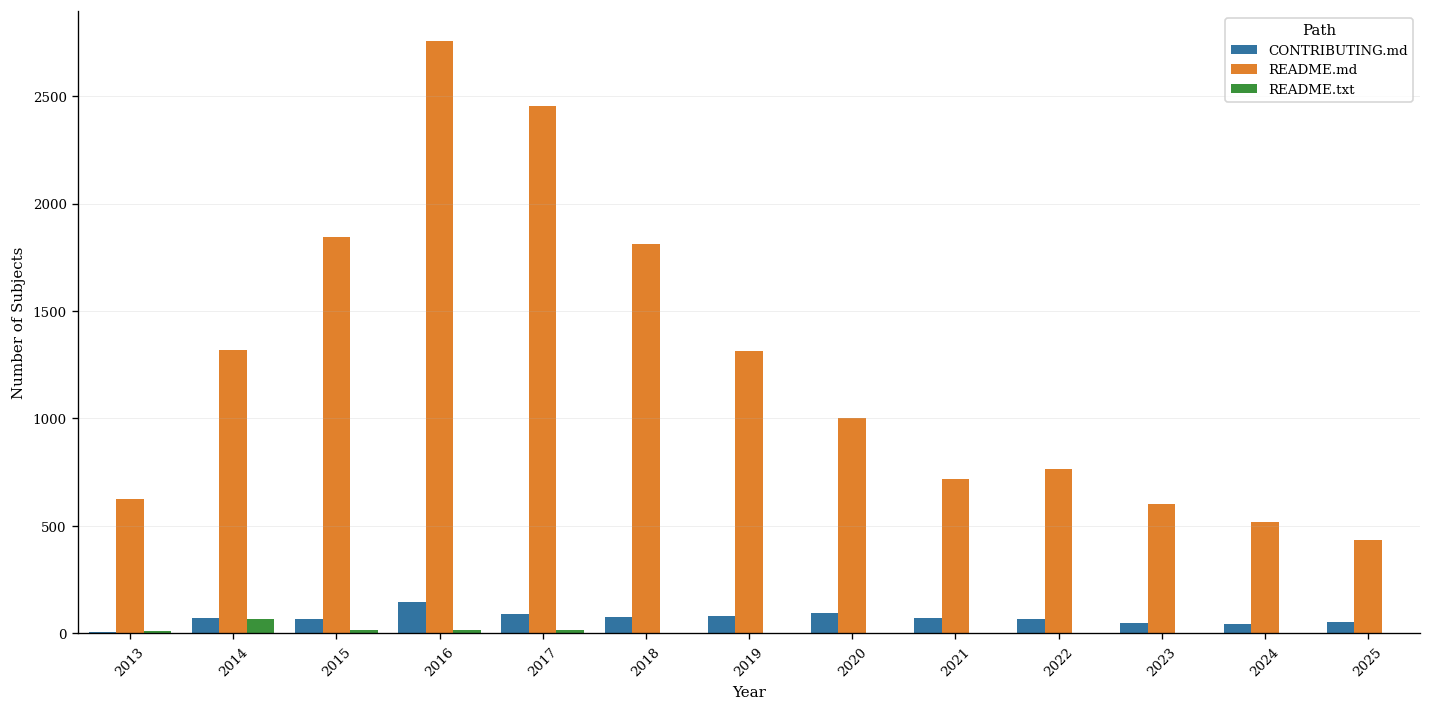

In [41]:
results_gb_year_path = (
    time_results
    .groupby(["year", "path"])
    .size()
    .reset_index(name="count")
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_gb_year_path,
    x="year",
    y="count",
    hue="path"
)

plt.xlabel("Year")
plt.ylabel("Number of Subjects")
plt.xticks(rotation=45)
plt.legend(title="Path")

plt.tight_layout()
plt.show()

/var/folders/88/6dbd9b356pg33wcpzcz2t4b40000gn/T/ipykernel_37501/3065887987.py:26: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack()


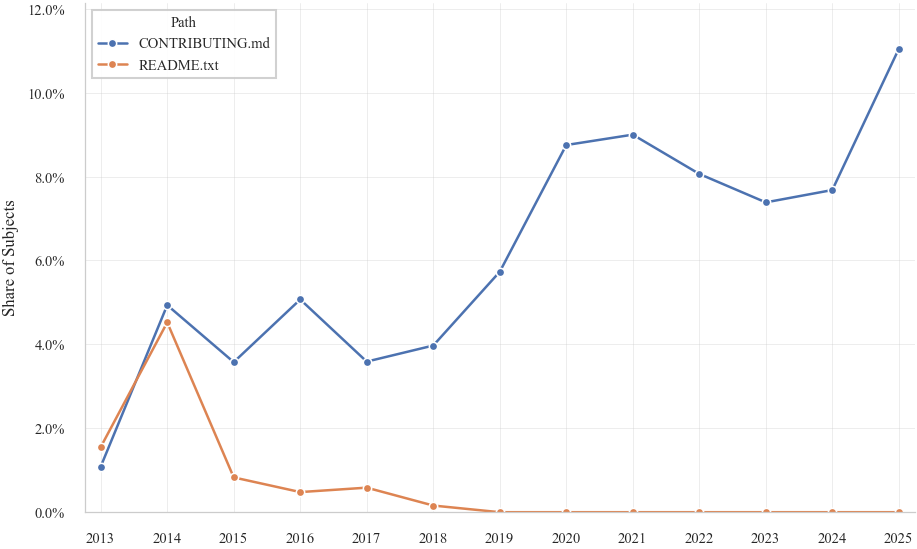

In [166]:
results_gb_year_path = (
    time_results
    .groupby(["year", "path"])
    .size()
    .reset_index(name="count")
)

results_gb_year_path["share"] = (
    results_gb_year_path["count"]
    / results_gb_year_path.groupby("year")["count"].transform("sum")
)

PATHS_OF_INTEREST = ["CONTRIBUTING.md", "README.txt"]

_df = (
    results_gb_year_path[
        results_gb_year_path["path"].isin(PATHS_OF_INTEREST)
    ]
    .copy()
)

_df = (
    _df
    .set_index(["year", "path"])
    .unstack(fill_value=0)
    .stack()
    .reset_index()
)

fig, ax = plt.subplots(figsize=ieee_figsize("double"))

sns.lineplot(
    data=_df,
    x="year",
    y="share",
    hue="path",
    marker="o",
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("Share of Subjects")

ax.set_xticks(_df["year"].unique())

from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_ylim(0, _df["share"].max() * 1.1)
ax.margins(x=0.02)

ax.legend(title="Path", loc="upper left")

save_ieee_figure(fig, "share_contributing_readme_txt", save_pdf=True)

plt.show()

/var/folders/88/6dbd9b356pg33wcpzcz2t4b40000gn/T/ipykernel_37501/1927124460.py:12: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack()


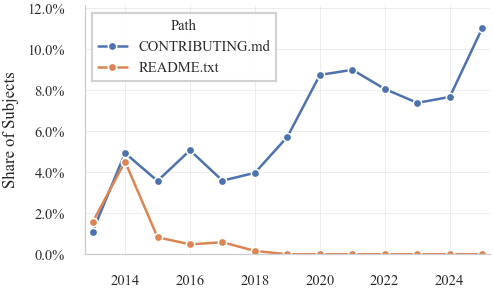

In [165]:
_df = (
    results_gb_year_path[
        results_gb_year_path["path"].isin(PATHS_OF_INTEREST)
    ]
    .copy()
)

_df = (
    _df
    .set_index(["year", "path"])
    .unstack(fill_value=0)
    .stack()
    .reset_index()
)

fig, ax = plt.subplots(figsize=ieee_figsize("single"))

sns.lineplot(
    data=_df,
    x="year",
    y="share",
    hue="path",
    marker="o",
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("Share of Subjects")

from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_ylim(0, _df["share"].max() * 1.1)
ax.margins(x=0.02)

ax.legend(title="Path", loc="upper left")

save_ieee_figure(fig, "share_contributing_readme_txt_single", save_pdf=True)

plt.show()

### Repository Demographics

Next, we take a look at the repository specific demographics…

#### Repository Count Overall

In [43]:
repo_count = len(repos)

assert(results["full_name_of_repo"].nunique() == repo_count)
print(f"{repo_count} repositories contributed to the results.")

362 repositories contributed to the results.


#### Repositories Come and Go…

Now, we create a table showing how many repositories were born in a year and how many repositories had their last activity in a year.

In [44]:
_repos_copy = repos.copy()

_repos_copy["year_of_first_activity"] = _repos_copy["first_activity"].dt.year
_repos_copy["year_of_last_activity"] = _repos_copy["last_activity"].dt.year

_repos_come = (
    _repos_copy
    .groupby("year_of_first_activity")
    .size()
    .reset_index(name="count")
)

_repos_come.set_index("year_of_first_activity", drop=True, inplace=True)
_repos_come.rename_axis("year", inplace=True)

_repos_come = years.join(    
    _repos_come.rename_axis("year"),
    how="left"
)

_repos_come["count"] = _repos_come["count"].fillna(0).astype(int)
_repos_come = _repos_come.rename(columns={"count": "n_repos_come"})

_repos_go = (
    _repos_copy
    .groupby("year_of_last_activity")
    .size()
    .reset_index(name="count")
)

_repos_go.set_index("year_of_last_activity", drop=True, inplace=True)
_repos_go.rename_axis("year", inplace=True)

_repos_go = years.join(
    _repos_go.rename_axis("year"),
    how="left"
)

_repos_go["count"] = _repos_go["count"].fillna(0).astype(int)
_repos_go = _repos_go.rename(columns={"count": "n_repos_go"})

repos_come_and_go = _repos_come.join(
    _repos_go,
    how="left",
)

repos_come_and_go["n_dead"] = (
    repos_come_and_go["n_repos_go"]
    .cumsum()
    .shift(1, fill_value=0)
)

repos_come_and_go["n_alive"] = (
    repos_come_and_go["n_repos_come"].cumsum()
    - repos_come_and_go["n_dead"]
)

In [45]:
repos_come_and_go

,n_repos_come,n_repos_go,n_dead,n_alive
year,,,,
2008,1,0,0,1
2009,4,0,0,5
2010,6,0,0,11
2011,4,0,0,15
2012,28,0,0,43
2013,44,0,0,87
2014,72,0,0,159
2015,65,2,0,224
2016,68,2,2,290


In summary, this approach ensures that:
- repositories contribute to the active count in the year they are created,
- and repositories that become inactive are only removed from the active population in the following year.

This results in a temporally consistent estimate of the number of active repositories over time.

LaTeX table export:

In [119]:
latex_tables(ROOT).mkdir(parents=True, exist_ok=True)

_df = repos_come_and_go[["n_repos_come", "n_repos_go", "n_alive"]]

(
    _df
        .rename_axis("Year", axis="index")
        .rename(
            columns={
                "n_repos_come": r"$n_{\mathrm{come}}$",
                "n_repos_go": r"$n_{\mathrm{go}}$",
                "n_alive": r"$n_{\mathrm{alive}}$",
            }
        )
).to_latex(
    latex_tables(ROOT) / "repos_come_and_go.tex",
    escape=False,
)

#### Age Groups Today

What do the age groups look like Today?

In [46]:
group_keys = ["age_group"]

cfg = SummarizeConfig(
    include_metrics=(
        "n_repos",
    ),
    group_keys=tuple(group_keys),
)

repos_per_age_group_today = (
    repos
    .groupby(group_keys)[["full_name_of_repo"]]
    .apply(lambda g: summarize_subjects_configurable(g, cfg))
)

In [47]:
repos_per_age_group_today

,n_repos
age_group,
0,8
1,4
2,3
3,3
4,7
5,6
6,4
7,27
8,53


LaTeX table export:

In [120]:
latex_tables(ROOT).mkdir(parents=True, exist_ok=True)

_df = repos_per_age_group_today

(
    _df
        .rename_axis("Age Group", axis="index")
        .rename(
            columns={
                "n_repos": r"$n_{\mathrm{repos}}$",
            }
        )
).to_latex(
    latex_tables(ROOT) / "repos_per_age_group_today.tex",
    escape=False,
)

#### At What Age Do Repositories Have Their First Subject?

In [48]:
_group_keys = ["age_group_at_first_subject"]

_cfg = SummarizeConfig(
    include_metrics=(
        "n_repos",
    ),
    group_keys=tuple(_group_keys),
)

age_at_first_subject = (
    repos
    .groupby(_group_keys)[["full_name_of_repo"]]
    .apply(lambda g: summarize_subjects_configurable(g, _cfg))
)

age_at_first_subject["share"] = (
    age_at_first_subject["n_repos"] / repo_count
)

In [49]:
age_at_first_subject

,n_repos,share
age_group_at_first_subject,,
0,337,0.930939
1,6,0.016575
2,9,0.024862
3,4,0.011050
5,1,0.002762
6,2,0.005525
7,1,0.002762
8,2,0.005525


LaTeX table export:

In [122]:
latex_tables(ROOT).mkdir(parents=True, exist_ok=True)

_df = age_at_first_subject

(
    _df
        .rename_axis("Age Group", axis="index")
        .rename(
            columns={
                "n_repos": r"$n_{\mathrm{repos}}$",
                "share": "Share",
            }
        )
).to_latex(
    latex_tables(ROOT) / "age_at_first_subject.tex",
    escape=False,
    float_format="%.2f",
)

#### Survivors

In [50]:
survivors = (
    repos
    .groupby("age_group")
    .size()
    .reset_index(name="count")
)

survivors.set_index("age_group", drop=True, inplace=True)

survivors["n_alive"] = survivors["count"][::-1].cumsum()[::-1]

survivors = survivors.rename(columns={"count": "n_dead"})

survivors["n_survivors"] = survivors["n_alive"] - survivors["n_dead"]

In [51]:
survivors

,n_dead,n_alive,n_survivors
age_group,,,
0,8,362,354
1,4,354,350
2,3,350,347
3,3,347,344
4,7,344,337
5,6,337,331
6,4,331,327
7,27,327,300
8,53,300,247


LaTeX table export:

In [123]:
latex_tables(ROOT).mkdir(parents=True, exist_ok=True)

_df = survivors[["n_alive", "n_survivors"]]

(
    _df
        .rename_axis("Age Group", axis="index")
        .rename(
            columns={
                "n_alive": r"$n_{\mathrm{alive}}$",
                "n_survivors": r"$n_{\mathrm{survivors}}$",
            }
        )
).to_latex(
    latex_tables(ROOT) / "age_group_survivors.tex",
    escape=False,
)

#### Per Year: Subject Count per Repository

In [144]:
time_results_gb["n_subjects_per_active_repo"] = (
    time_results_gb["n_subjects"] / time_results_gb["n_repos"]
)

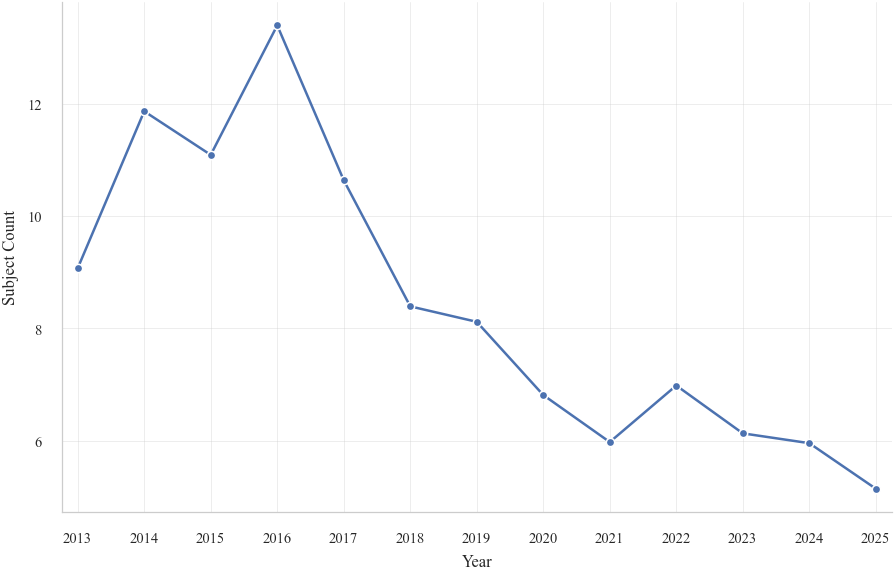

In [145]:
_df = time_results_gb.copy()

fig, ax = plt.subplots(figsize=ieee_figsize("double"))

sns.lineplot(
    data=_df,
    x="year",
    y="n_subjects_per_active_repo",
    marker="o",
    ax=ax
)

ax.set_xlabel("Year")
ax.set_ylabel("Subject Count")

ax.set_xticks(_df.index)

ax.margins(x=0.02)

save_ieee_figure(fig, "subject_count_per_active_repo_per_year", save_pdf=True)

plt.show()

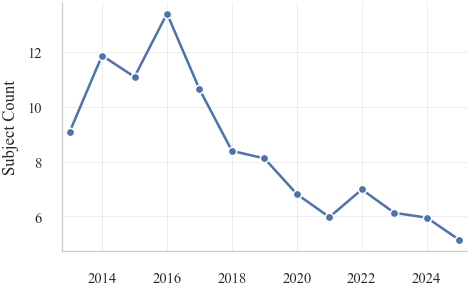

In [161]:
_df = time_results_gb.copy()

fig, ax = plt.subplots(figsize=ieee_figsize("single"))

sns.lineplot(
    data=_df,
    x="year",
    y="n_subjects_per_active_repo",
    marker="o",
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("Subject Count")

ax.margins(x=0.02)

save_ieee_figure(fig, "subject_count_per_active_repo_per_year_single", save_pdf=True)

plt.show()

#### Each Year, How Many Repositories Have A Subject?

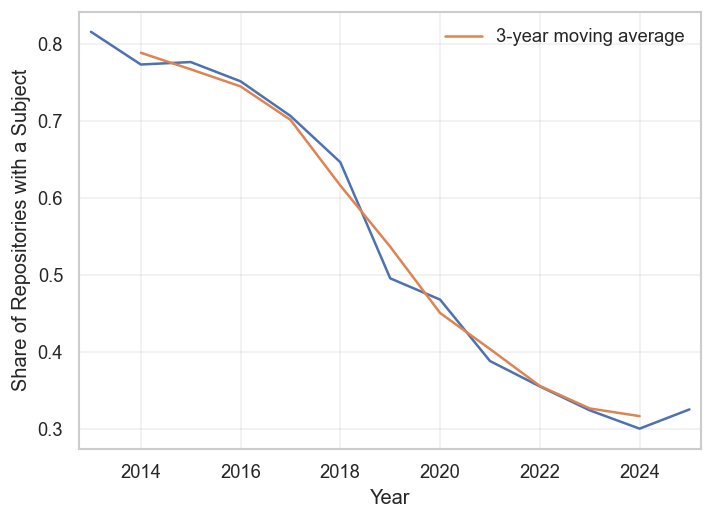

In [52]:
time_results_gb = time_results_gb.join(
    repos_come_and_go["n_alive"],
    how="left",
)

_active_repos_per_year = time_results_gb.copy()

_active_repos_per_year["share"] = (
    _active_repos_per_year["n_repos"] / _active_repos_per_year["n_alive"]
)

_active_repos_per_year["share_rolling_mean_3"] = (
    _active_repos_per_year["share"].rolling(3, center=True).mean()
)

fig, ax = plt.subplots(figsize=set_size(170, 120))

ax.plot(_active_repos_per_year.index, _active_repos_per_year["share"])
ax.plot(_active_repos_per_year.index, _active_repos_per_year["share_rolling_mean_3"], label="3-year moving average")

ax.set_xlabel("Year")
ax.set_ylabel("Share of Repositories with a Subject")

ax.legend(frameon=False, loc="best")
ax.margins(x=0.02)

plt.show()

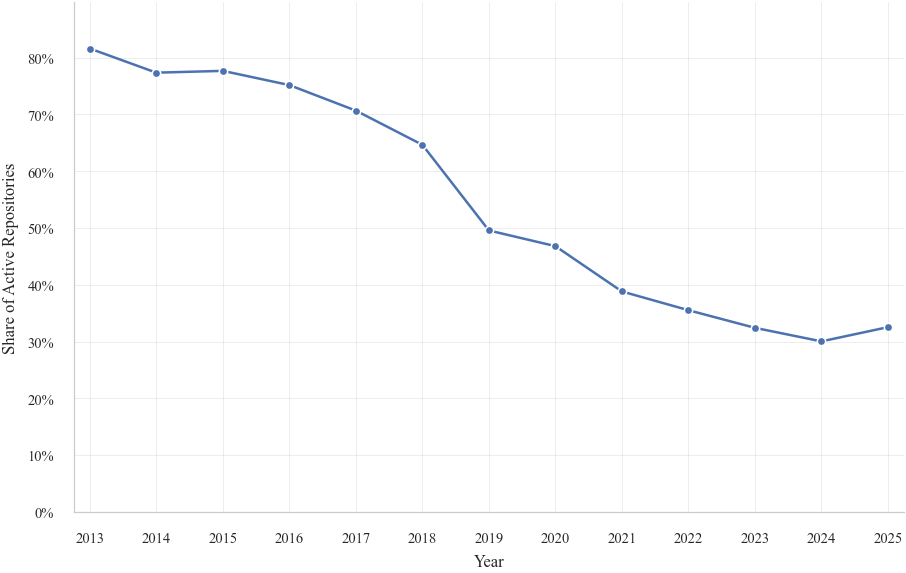

In [153]:
_df = time_results_gb.copy()

_df["share"] = (
    _df["n_repos"] / _df["n_alive"]
)

fig, ax = plt.subplots(figsize=ieee_figsize("double"))

sns.lineplot(
    data=_df,
    x="year",
    y="share",
    marker="o",
    ax=ax
)

ax.set_xlabel("Year")
ax.set_ylabel("Share of Active Repositories")

ax.set_xticks(_df.index)

from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_ylim(0, _df["share"].max() * 1.1)
ax.margins(x=0.02)

save_ieee_figure(fig, "active_repos_per_year", save_pdf=True)

plt.show()

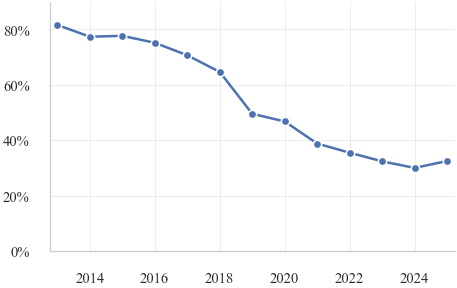

In [168]:
_df = time_results_gb.copy()

_df["share"] = (
    _df["n_repos"] / _df["n_alive"]
)

fig, ax = plt.subplots(figsize=ieee_figsize("single"))

sns.lineplot(
    data=_df,
    x="year",
    y="share",
    marker="o",
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("")

from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_ylim(0, _df["share"].max() * 1.1)
ax.margins(x=0.02)

save_ieee_figure(fig, "active_repos_per_year_single", save_pdf=True)

plt.show()

#### Per Age Group: Subject Count Per Repository

Over the lifetime of a repo, how many subjects per active repo? How does that number evolve?

*-> How does the commitment RE project documentation evolve over the lifetime of a repository?*

In [143]:
project_results_gb["n_subjects_per_active_repo"] = (
    project_results_gb["n_subjects"] / project_results_gb["n_repos"]
)

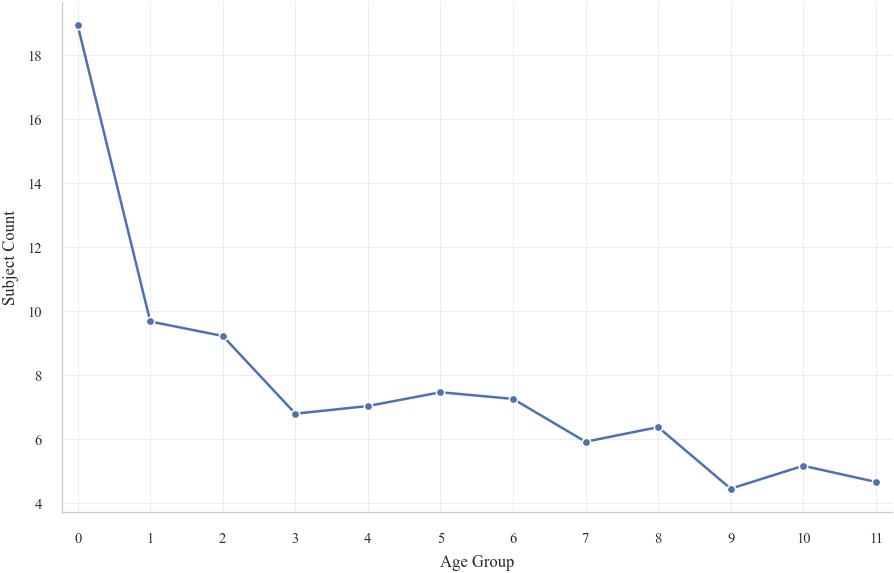

In [142]:
_df = project_results_gb.copy()

fig, ax = plt.subplots(figsize=ieee_figsize("double"))

sns.lineplot(
    data=_df,
    x="age_group",
    y="n_subjects_per_active_repo",
    marker="o",
    ax=ax
)

ax.set_xlabel("Age Group")
ax.set_ylabel("Subject Count")

ax.set_xticks(_df.index)

ax.margins(x=0.02)

save_ieee_figure(fig, "subject_count_per_active_repo_per_age_group", save_pdf=True)

plt.show()

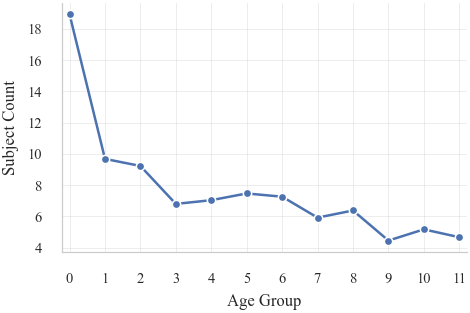

In [162]:
_df = project_results_gb.copy()

fig, ax = plt.subplots(figsize=ieee_figsize("single"))

sns.lineplot(
    data=_df,
    x="age_group",
    y="n_subjects_per_active_repo",
    marker="o",
    ax=ax
)

ax.set_xlabel("Age Group")
ax.set_ylabel("Subject Count")

ax.set_xticks(_df.index)

ax.margins(x=0.02)

save_ieee_figure(fig, "subject_count_per_active_repo_per_age_group_single", save_pdf=True)

plt.show()

#### Per Age Group: Share of Active Repositories

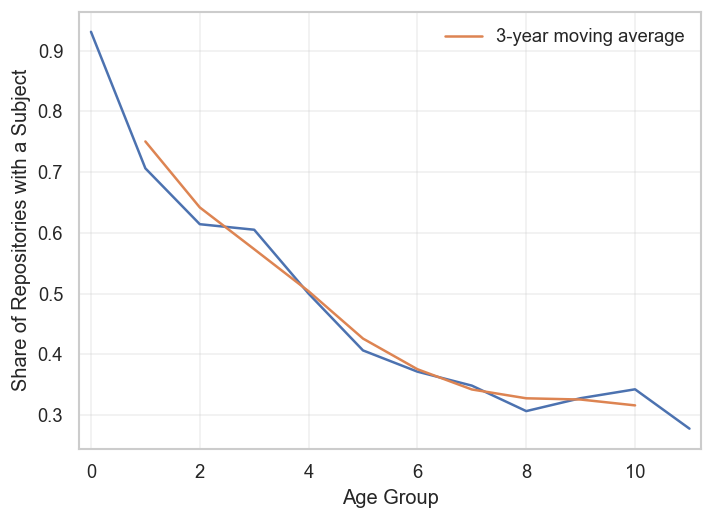

In [ ]:
project_results_gb = project_results_gb.join(
    survivors["n_alive"],
    how="left",
)

In [ ]:

_active_repos_per_age_group = project_results_gb.copy()

_active_repos_per_age_group["share"] = (
    _active_repos_per_age_group["n_repos"] / _active_repos_per_age_group["n_alive"]
)

_df = _active_repos_per_age_group.copy()

_df["share_rolling_mean_3"] = (
    _df["share"].rolling(3, center=True).mean()
)

fig, ax = plt.subplots(figsize=set_size(170, 120))

ax.plot(_df.index, _df["share"])
ax.plot(_df.index, _df["share_rolling_mean_3"], label="3-year moving average")

ax.set_xlabel("Age Group")
ax.set_ylabel("Share of Repositories with a Subject")

ax.legend(frameon=False, loc="best")
ax.margins(x=0.02)

plt.show()

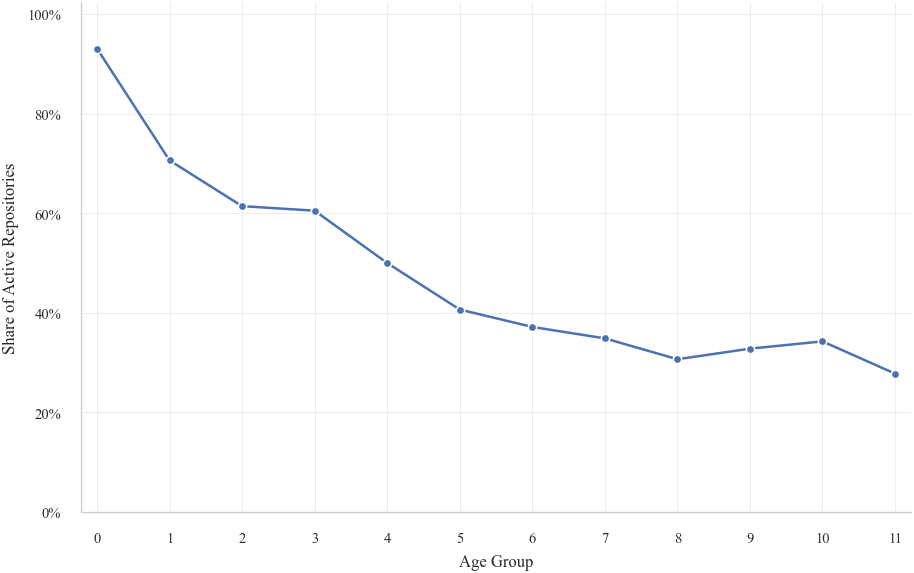

In [135]:
_df = project_results_gb.copy()

_df["share"] = (
    _df["n_repos"] / _df["n_alive"]
)

fig, ax = plt.subplots(figsize=ieee_figsize("double"))

sns.lineplot(
    data=_df,
    x="age_group",
    y="share",
    marker="o",
    ax=ax
)

ax.set_xlabel("Age Group")
ax.set_ylabel("Share of Active Repositories")

ax.set_xticks(_df.index)

from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_ylim(0, _df["share"].max() * 1.1)
ax.margins(x=0.02)

save_ieee_figure(fig, "active_repos_per_age_group", save_pdf=True)

plt.show()

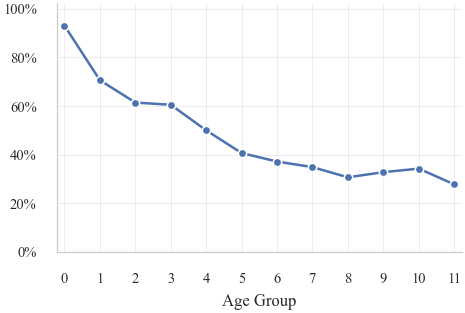

In [169]:
_df = project_results_gb.copy()

_df["share"] = (
    _df["n_repos"] / _df["n_alive"]
)

fig, ax = plt.subplots(figsize=ieee_figsize("single"))

sns.lineplot(
    data=_df,
    x="age_group",
    y="share",
    marker="o",
    ax=ax
)

ax.set_xlabel("Age Group")
ax.set_ylabel("")

ax.set_xticks(_df.index)

from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_ylim(0, _df["share"].max() * 1.1)
ax.margins(x=0.02)

save_ieee_figure(fig, "active_repos_per_age_group_single", save_pdf=True)

plt.show()

#### Boxplot: Repository Age

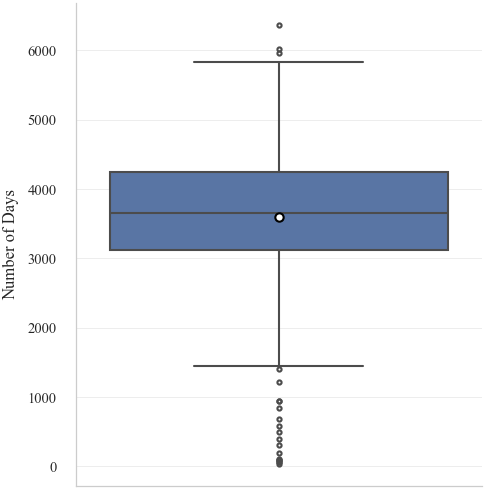

In [176]:
fig, ax = plt.subplots(figsize=ieee_figsize("single", ratio=1.2))

sns.boxplot(
    y=repos["age"],
    width=0.3,
    fliersize=2,
    linewidth=1,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 4,
    },
    ax=ax
)

ax.set_ylabel("Number of Days")
ax.set_xlabel("")
ax.set_xticks([])

ax.margins(x=0.1)

save_ieee_figure(fig, "repo_age_boxplot", save_pdf=True)

plt.show()

In [56]:
# print(boxplot_stats(repos["age"]))

#### Boxplot: Subject Count Per Repository

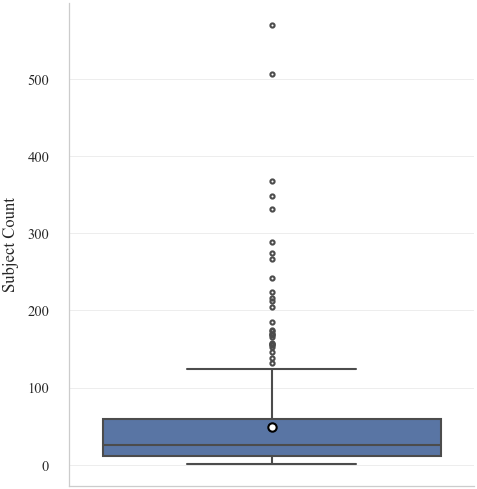

In [171]:
_df = (
    results
    .groupby(["full_name_of_repo"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=ieee_figsize("single", ratio=1.2))

sns.boxplot(
    y=_df["count"],
    width=0.3,
    fliersize=2,
    linewidth=1,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 4,
    },
    ax=ax
)

ax.set_ylabel("Subject Count")
ax.set_xlabel("")
ax.set_xticks([])

ax.margins(x=0.1)

save_ieee_figure(fig, "subject_count_per_repo_boxplot", save_pdf=True)

plt.show()

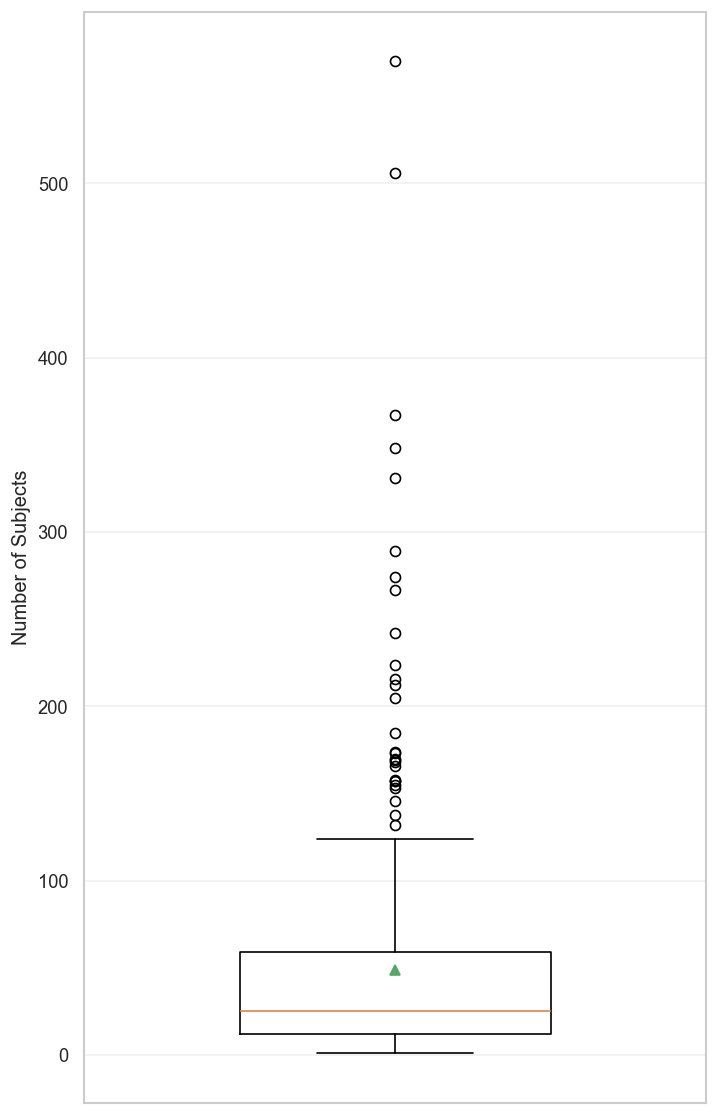

In [57]:
results_gb_repo = (
    results
    .groupby(["full_name_of_repo"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=set_size(170, 300))

ax.boxplot(
    results_gb_repo["count"],
    vert=True,
    widths=0.5,
    showmeans=True,
    meanline=False,
    whis=1.5,
)

ax.set_ylabel("Number of Subjects")
ax.set_xticks([])

plt.show()

In [58]:
# print(boxplot_stats(results_gb_repo["count"]))

#### More Statistics…

Overall, how many CCDC events per repo (median)? How many channels per repo (median)?

In [173]:
group_keys = ["full_name_of_repo"]

cfg = SummarizeConfig(
    include_metrics=(
        "positive_rate",
        "n_distinct_channels",
    ),
    group_keys=tuple(group_keys),
)

positive_rate_and_detected_channels_per_repo = (
    results
    .groupby(group_keys)[["is_ccdc_event", "detected_channels"]]
    .apply(lambda g: summarize_subjects_configurable(g, cfg))
)

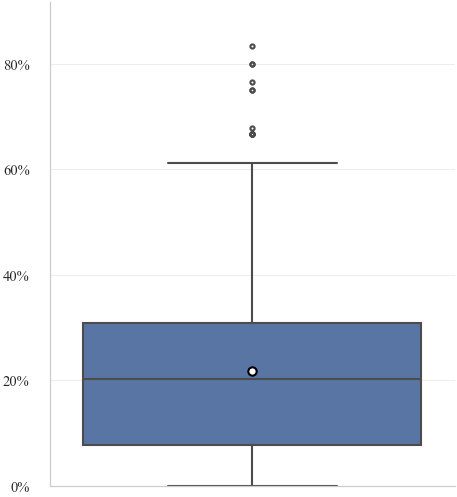

In [178]:
fig, ax = plt.subplots(figsize=ieee_figsize("single", ratio=1.2))

sns.boxplot(
    y=positive_rate_and_detected_channels_per_repo["positive_rate"],
    width=0.3,
    fliersize=2,
    linewidth=1,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 4,
    },
    ax=ax
)

ax.set_ylabel("")
ax.set_xlabel("")
ax.set_xticks([])

from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, positive_rate_and_detected_channels_per_repo["positive_rate"].max() * 1.1)

ax.margins(x=0.1)

save_ieee_figure(fig, "ccdc_events_per_repo_boxplot", save_pdf=True)

plt.show()

In [60]:
print(boxplot_stats(positive_rate_and_detected_channels_per_repo["positive_rate"]))

n                362.000000
min                0.000000
max                0.833333
mean               0.217253
median             0.201351
q1                 0.077429
q3                 0.307692
iqr                0.230263
lower_whisker      0.000000
upper_whisker      0.611111
n_outliers        14.000000
dtype: float64


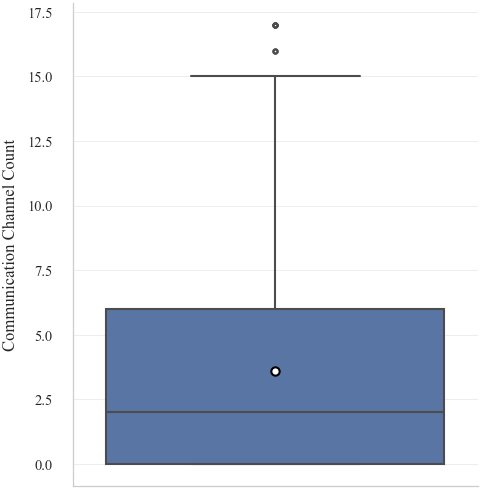

In [174]:
fig, ax = plt.subplots(figsize=ieee_figsize("single", ratio=1.2))

sns.boxplot(
    y=positive_rate_and_detected_channels_per_repo["n_distinct_channels"],
    width=0.3,
    fliersize=2,
    linewidth=1,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 4,
    },
    ax=ax
)

ax.set_ylabel("Communication Channel Count")
ax.set_xlabel("")
ax.set_xticks([])

ax.margins(x=0.1)

save_ieee_figure(fig, "channel_count_per_repo_boxplot", save_pdf=True)

plt.show()

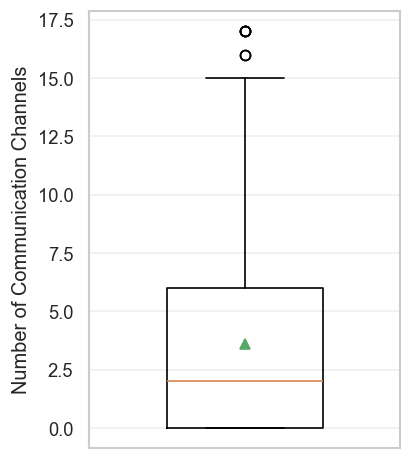

In [61]:
fig, ax = plt.subplots(figsize=set_size(85, 120))

ax.boxplot(
    positive_rate_and_detected_channels_per_repo["n_distinct_channels"],
    vert=True,
    widths=0.5,
    showmeans=True,
    meanline=False,
    whis=1.5,
)

ax.set_ylabel("Number of Communication Channels")
ax.set_xticks([])

plt.show()

In [62]:
print(boxplot_stats(positive_rate_and_detected_channels_per_repo["n_distinct_channels"]))

n                362.000000
min                0.000000
max               17.000000
mean               3.593923
median             2.000000
q1                 0.000000
q3                 6.000000
iqr                6.000000
lower_whisker      0.000000
upper_whisker     15.000000
n_outliers         6.000000
dtype: float64


### CCDC Event Demographics

We filter our results to define a dedicated data frame that only includes CCDC events:

In [63]:
ccdc_events = results[results["is_ccdc_event"] == True]

How many CCDC events are without any detected channel?

In [64]:
empty_ccdc_events = ccdc_events[ccdc_events["detected_channels"] == ()]

print(f"There are {len(empty_ccdc_events)} CCDC events without any detected channel.")

_share = (
    len(empty_ccdc_events) / len(ccdc_events)
)

print(f"That is {_share*100:.2f}% of all CCDC events.")

There are 1932 CCDC events without any detected channel.
That is 53.44% of all CCDC events.


When did these happen?

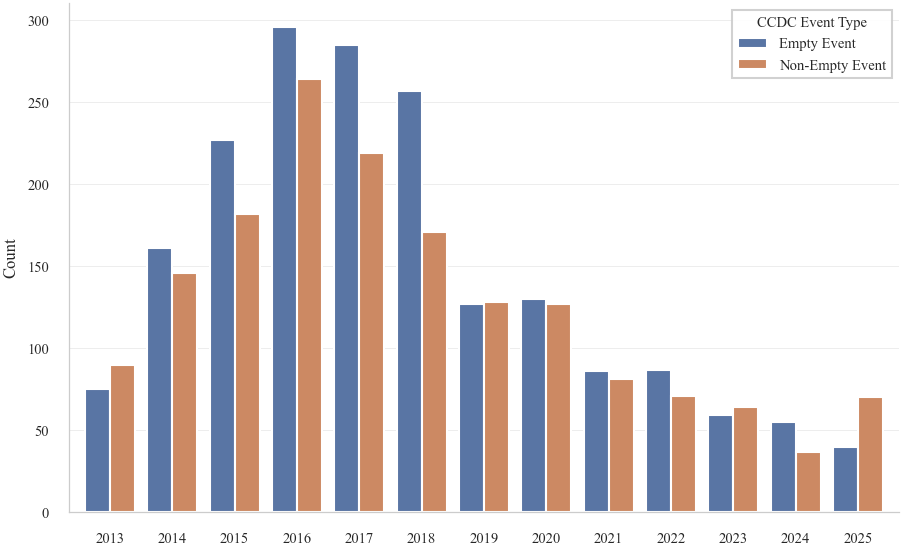

In [187]:
_ccdc_events = time_results[time_results["is_ccdc_event"] == True].copy()

_ccdc_events["is_empty"] = _ccdc_events["detected_channels"] == ()

_ccdc_events["is_empty_label"] = _ccdc_events["is_empty"].map({
    True: "Empty Event",
    False: "Non-Empty Event"
})

_empty_vs_non_empty = (
    _ccdc_events
    .groupby(["year", "is_empty_label"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=ieee_figsize("double"))

sns.barplot(
    data=_empty_vs_non_empty,
    x="year",
    y="count",
    hue="is_empty_label",
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("Count")

ax.margins(x=0.02)

ax.legend(title="CCDC Event Type", loc="upper right")

save_ieee_figure(fig, "empty_vs_non_empty_ccdc_events", save_pdf=True)

plt.show()

## Repository-independent Perspective

#### CCDC Event Rate over the Years

Over the years, how did the CCDC event rate – the positive rate – evolve?

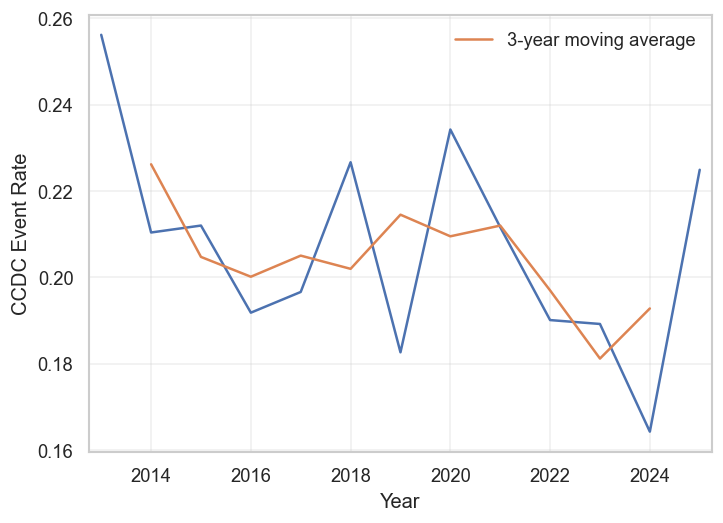

In [66]:
_df = time_results_gb.copy()

_df["positive_rate_rolling_mean_3"] = (
    _df["positive_rate"].rolling(3, center=True).mean()
)

fig, ax = plt.subplots(figsize=set_size(170, 120))

ax.plot(_df.index, _df["positive_rate"])
ax.plot(_df.index, _df["positive_rate_rolling_mean_3"], label="3-year moving average")

ax.set_xlabel("Year")
ax.set_ylabel("CCDC Event Rate")

ax.legend(frameon=False, loc="best")
ax.margins(x=0.02)

plt.show()

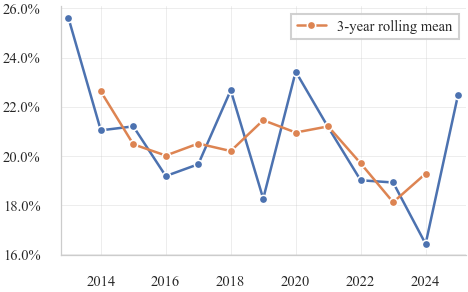

In [205]:
_df = time_results_gb.copy()

_df["share"] = (
    _df["n_repos"] / _df["n_alive"]
)

_df["positive_rate_rolling_mean_3"] = (
    _df["positive_rate"].rolling(3, center=True).mean()
)

fig, ax = plt.subplots(figsize=ieee_figsize("single"))

sns.lineplot(
    data=_df,
    x="year",
    y="positive_rate",
    marker="o",
    ax=ax,
)

sns.lineplot(
    data=_df,
    x="year",
    y="positive_rate_rolling_mean_3",
    marker="o",
    ax=ax,
    label="3-year rolling mean"
)

ax.set_xlabel("")
ax.set_ylabel("")

from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.margins(x=0.02)

ax.legend(loc="upper right")

save_ieee_figure(fig, "ccdc_events_per_year", save_pdf=True)

plt.show()

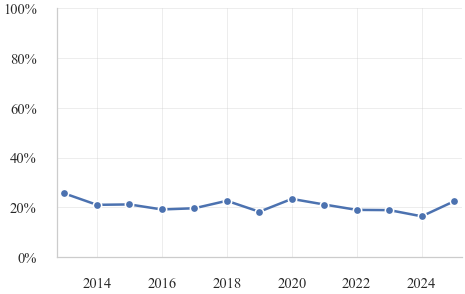

In [201]:
_df = time_results_gb.copy()

_df["share"] = (
    _df["n_repos"] / _df["n_alive"]
)

_df["positive_rate_rolling_mean_3"] = (
    _df["positive_rate"].rolling(3, center=True).mean()
)

fig, ax = plt.subplots(figsize=ieee_figsize("single"))

sns.lineplot(
    data=_df,
    x="year",
    y="positive_rate",
    marker="o",
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("")

from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_ylim(0, 1)

ax.margins(x=0.02)

save_ieee_figure(fig, "ccdc_events_per_year_zoomed_out", save_pdf=True)

plt.show()

#### Out of all Repositories that were alive, how many had a CCDC Event?

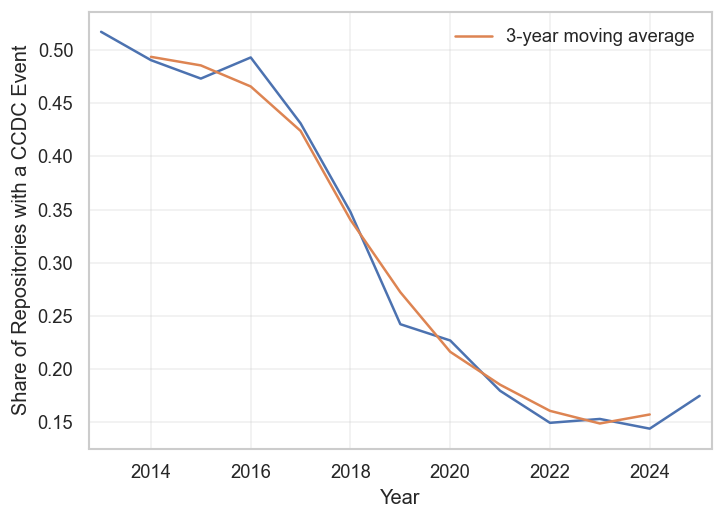

In [ ]:
time_results_gb["share_pos_repos"] = (
    time_results_gb["n_pos_repos"] / time_results_gb["n_alive"]
)

In [ ]:

_df = time_results_gb.copy()

_df["share_rolling_mean_3"] = (
    _df["share_pos_repos"].rolling(3, center=True).mean()
)

fig, ax = plt.subplots(figsize=set_size(170, 120))

ax.plot(_df.index, _df["share_pos_repos"])
ax.plot(_df.index, _df["share_rolling_mean_3"], label="3-year moving average")

ax.set_xlabel("Year")
ax.set_ylabel("Share of Repositories with a CCDC Event")

ax.legend(frameon=False, loc="best")
ax.margins(x=0.02)

plt.show()

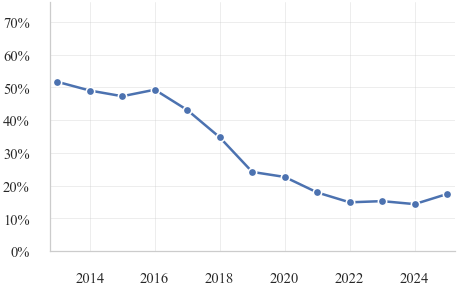

In [218]:
_df = time_results_gb.copy()

fig, ax = plt.subplots(figsize=ieee_figsize("single"))

sns.lineplot(
    data=_df,
    x="year",
    y="share_pos_repos",
    marker="o",
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("")

from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_ylim(0, 0.76)

ax.margins(x=0.02)

save_ieee_figure(fig, "share_of_pos_repos_per_year", save_pdf=True)

plt.show()

I think it is fascinating that the CCDC event rate is relatively stable over the years, while the share of repositories that have a CCDC event is dropping drastically… Having said that, let's also plot the number of CCDC events a positive repositories is responsible for, on average, per year.

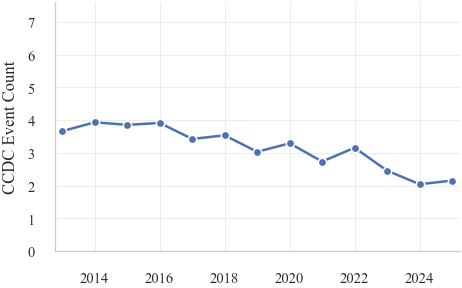

In [223]:
_df = time_results_gb.copy()

_df["n_ccdc_events_per_pos_repo_rolling_mean_3"] = (
    _df["n_ccdc_events_per_pos_repo"].rolling(3, center=True).mean()
)

# fig, ax = plt.subplots(figsize=set_size(170, 120))

# ax.plot(_df.index, _df["n_ccdc_events_per_pos_repo"])
# ax.plot(_df.index, _df["n_ccdc_events_per_pos_repo_rolling_mean_3"], label="3-year moving average")

# ax.set_xlabel("Year")
# ax.set_ylabel("Number of CCDC Events per Positive Repository")

# ax.legend(frameon=False, loc="best")
# ax.margins(x=0.02)

# plt.show()

fig, ax = plt.subplots(figsize=ieee_figsize("single"))

sns.lineplot(
    data=_df,
    x="year",
    y="n_ccdc_events_per_pos_repo",
    marker="o",
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("CCDC Event Count")

ax.set_ylim(0, 7.6)

ax.margins(x=0.02)

save_ieee_figure(fig, "ccdc_event_count_per_pos_repo_per_year", save_pdf=True)

plt.show()

#### Channel Diversity

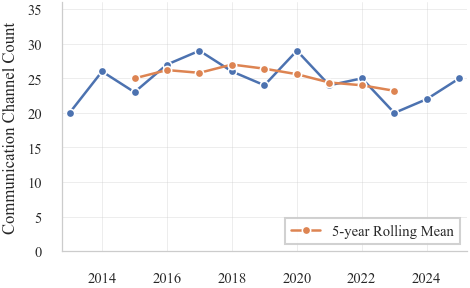

In [238]:
_df = time_results_gb.copy()

_df["rolling_mean_5"] = (
    _df["n_distinct_channels"].rolling(5, center=True).mean()
)

# fig, ax = plt.subplots(figsize=set_size(170, 120))

# ax.plot(_df.index, _df["n_distinct_channels"])
# ax.plot(_df.index, _df["rolling_mean_3"], label="3-year moving average")

# ax.set_xlabel("Year")
# ax.set_ylabel("Number of Distinct Communication Channels")

# ax.legend(frameon=False, loc="best")
# ax.margins(x=0.02)
# ax.set_ylim(17, 34)

# import matplotlib.ticker as ticker

# ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
# ax.yaxis.set_major_locator(ticker.MultipleLocator(2))

# plt.show()

fig, ax = plt.subplots(figsize=ieee_figsize("single"))

sns.lineplot(
    data=_df,
    x="year",
    y="n_distinct_channels",
    marker="o",
    ax=ax,
)

sns.lineplot(
    data=_df,
    x="year",
    y="rolling_mean_5",
    marker="o",
    ax=ax,
    label="5-year Rolling Mean"
)

ax.set_xlabel("")
ax.set_ylabel("Communication Channel Count")

ax.set_ylim(0, 36)

ax.legend(loc="lower right")

ax.margins(x=0.02)

save_ieee_figure(fig, "channel_diversity_over_time", save_pdf=True)

plt.show()

#### Communication Channel Count

We introduce a matrix that has a column for each channel and lists the channel count for a channel for a year.

In [249]:
cc_count_matrix = (
    results
    .explode("detected_channels")
    .groupby(["year", "detected_channels"])
    .size()
    .unstack(fill_value=0)
)

cc_count_matrix.columns.name = None
cc_count_matrix = cc_count_matrix.loc[:, cc_count_matrix.iloc[-1].sort_values(ascending=False).index]
# cc_count_matrix = cc_count_matrix[cc_count_matrix.sum().sort_values(ascending=False).index]

In [247]:
cc_count_matrix

,pull_request,website,fork,issues,github_issues,form,forum,mail,ping_on_github,github_wiki,...,gitter,irc,youtube,telegram,reddit,skype,newsletter,meetup,medium,zulip
year,,,,,,,,,,,,,,,,,,,,,
2013,9,18,13,24,6,19,23,30,5,1,...,0,8,0,0,0,0,0,0,0,0
2014,26,30,11,48,16,26,23,39,14,8,...,3,5,0,2,2,1,0,0,0,0
2015,39,29,37,32,13,39,40,50,20,5,...,2,4,0,0,0,0,0,0,0,0
2016,61,43,49,58,35,47,34,50,20,16,...,14,12,2,9,0,0,0,5,1,0
2017,47,40,29,48,15,63,42,33,20,11,...,8,4,8,6,1,0,3,0,3,0
2018,30,43,33,26,18,29,23,17,11,18,...,6,7,0,11,0,0,0,0,0,0
2019,24,24,24,24,13,24,24,37,9,11,...,2,6,0,1,0,0,0,0,1,0
2020,31,17,19,35,18,21,22,19,10,9,...,2,7,1,12,1,0,0,0,0,1
2021,18,20,12,20,7,20,14,12,8,5,...,3,5,0,2,1,0,0,0,0,0


##### Heatmap

Now, we plot a heatmap for the channel count matrix.

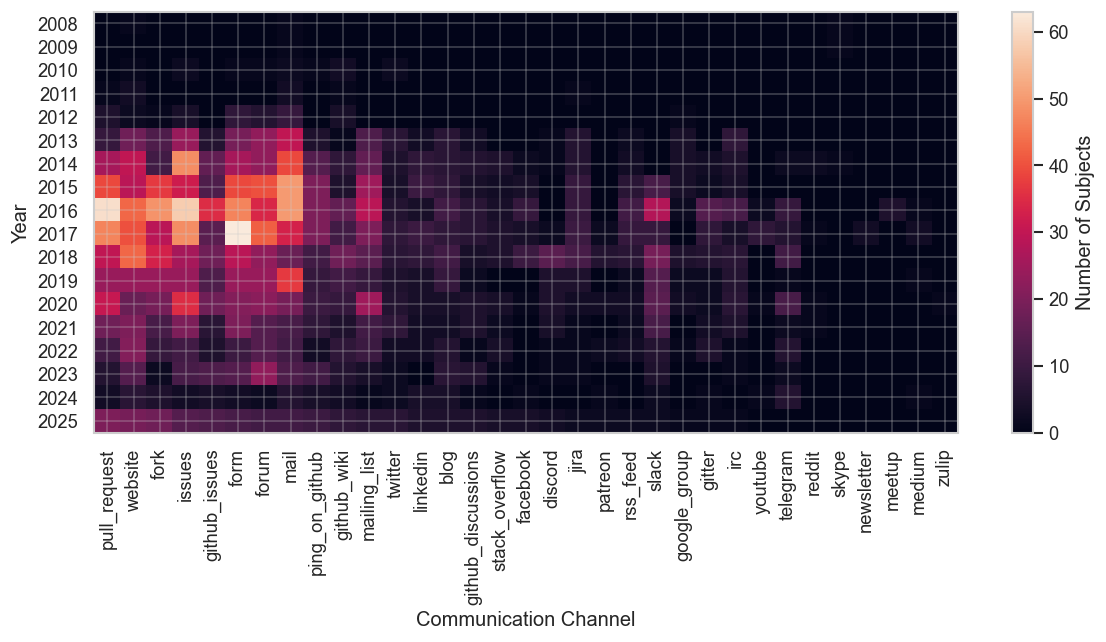

In [71]:
fig, ax = plt.subplots(figsize=set_size(255, 140))

im = ax.imshow(cc_count_matrix, aspect="auto")

ax.set_xlabel("Communication Channel")
ax.set_ylabel("Year")

ax.set_xticks(range(len(cc_count_matrix.columns)))
ax.set_xticklabels(cc_count_matrix.columns, rotation=90)

ax.set_yticks(range(len(cc_count_matrix.index)))
ax.set_yticklabels(cc_count_matrix.index)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Number of Subjects")

plt.tight_layout()
plt.show()

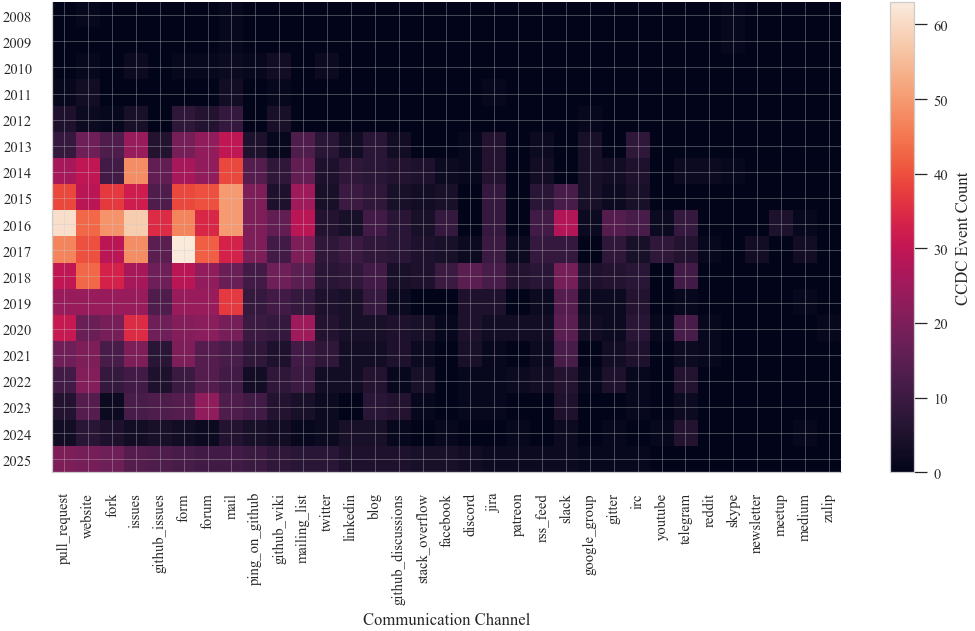

In [250]:
fig, ax = plt.subplots(figsize=ieee_figsize("double"))

im = ax.imshow(cc_count_matrix, aspect="auto")

ax.set_xlabel("Communication Channel")
ax.set_ylabel("")

ax.set_xticks(range(len(cc_count_matrix.columns)))
ax.set_xticklabels(cc_count_matrix.columns, rotation=90)

ax.set_yticks(range(len(cc_count_matrix.index)))
ax.set_yticklabels(cc_count_matrix.index)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("CCDC Event Count")

plt.tight_layout()

save_ieee_figure(fig, "cc_count_heatmap", save_pdf=True)

plt.show()

##### Line Plot

Let's also plot how the count of a certain set of channels has evolved over the years.

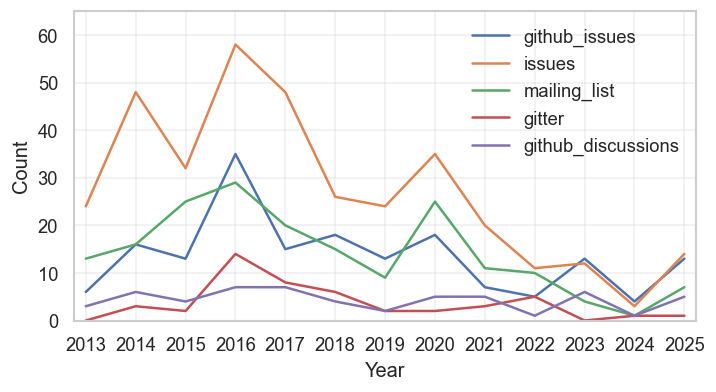

In [72]:
from matplotlib.ticker import MaxNLocator

CHANNELS_OF_INTEREST = [
    "github_issues",
    "issues",
    "mailing_list",
    "gitter",
    "github_discussions",
]

_df = (
    cc_count_matrix[[*CHANNELS_OF_INTEREST]]
)

_df = _df.loc[_df.index >= 2013]

fig, ax = plt.subplots(figsize=set_size(170, 85))

for ghc in CHANNELS_OF_INTEREST:
    ax.plot(_df.index, _df[ghc], label=ghc)

ax.xaxis.set_major_locator(
    MaxNLocator(integer=True)
)

ax.set_xlabel("Year")
ax.set_ylabel("Count")

ax.legend(frameon=False, loc="best")
ax.margins(x=0.02)
ax.set_ylim(0, 65)

import matplotlib.ticker as ticker

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(10))

plt.show()

#### Channels per CCDC Event

In [73]:
_ccdc_events = time_results[time_results["is_ccdc_event"] == True]

_vc_detected_channels_per_year = (
    _ccdc_events
    .groupby("year")[["detected_channels"]]
    .apply(vc_detected_channels)
)

_vc_stats_per_year = (
    _vc_detected_channels_per_year
    .reset_index()
    .groupby("year")["count"]
    .apply(value_counts_stats)
).unstack(fill_value=0)
_vc_stats_per_year = col_to_int(_vc_stats_per_year, INT_COLS_OF_VC_STATS)

vc_detected_channels_per_year = _vc_detected_channels_per_year.reset_index()

cc_count_per_year = _vc_stats_per_year[["total_count"]].join(
    time_results_gb["n_ccdc_events"],
    how="left",
)

cc_count_per_year["ratio"] = (
    cc_count_per_year["total_count"] / cc_count_per_year["n_ccdc_events"]
)

In [74]:
cc_count_per_year

,total_count,n_ccdc_events,ratio
year,,,
2013,202,165,1.224242
2014,317,307,1.032573
2015,400,409,0.977995
2016,576,560,1.028571
2017,475,504,0.94246
2018,396,428,0.925234
2019,281,255,1.101961
2020,306,257,1.190661
2021,198,167,1.185629


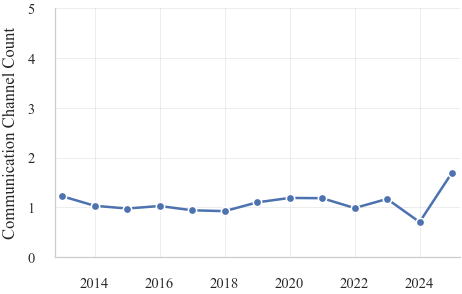

In [254]:
_df = cc_count_per_year.copy()

_df["ratio_rolling_mean_3"] = (
    _df["ratio"].rolling(3, center=True).mean()
)

# fig, ax = plt.subplots(figsize=set_size(170, 120))

# ax.plot(_df.index, _df["ratio"])
# ax.plot(_df.index, _df["ratio_rolling_mean_3"], label="3-year moving average")

# ax.set_xlabel("Year")
# ax.set_ylabel("Avg. Number of Detected Channels per CCDC Event")

# ax.legend(frameon=False, loc="best")
# ax.margins(x=0.02)
# ax.set_ylim(0, 3)

# import matplotlib.ticker as ticker

# ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

# plt.show()

fig, ax = plt.subplots(figsize=ieee_figsize("single"))

sns.lineplot(
    data=_df,
    x="year",
    y="ratio",
    marker="o",
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Communication Channel Count")

ax.set_ylim(0, 5)

ax.margins(x=0.02)

save_ieee_figure(fig, "cc_count_per_ccdc_event", save_pdf=True)

plt.show()

#### Top 5 Channels

In [76]:
top_5_per_year = (
    vc_detected_channels_per_year
        .sort_values(["year", "count"], ascending=[True, False])
        .groupby("year", dropna=False, sort=False)
        .head(5)
        .reset_index(drop=True)
)

How many channels have ever made it into the top 5 of year?

In [77]:
print(f"Answer: {top_5_per_year["channel"].nunique()}")

# print(f"These are:\n{top_5_per_year["channel"].unique()}")

Answer: 11


In [78]:
top_5_per_year[top_5_per_year["year"] == 2016]

,year,channel,count
15,2016,pull_request,61
16,2016,issues,58
17,2016,mail,50
18,2016,fork,49
19,2016,form,47


In [256]:
latex_tables(ROOT).mkdir(parents=True, exist_ok=True)

_df = top_5_per_year[top_5_per_year["year"] == 2016].copy()

_df = (
    _df
    .drop(columns="year")
    .reset_index(drop=True)
    .rename(
        columns={
            "channel": "Channel",
            "count": "Count",
        }
    )
)

_df.index = _df.index + 1
_df.index.name = "Rank"

_df.to_latex(
    latex_tables(ROOT) / "top_5_channels_2016.tex",
    escape=False,
    index=True,
)

In [257]:
latex_tables(ROOT).mkdir(parents=True, exist_ok=True)

_df = top_5_per_year[top_5_per_year["year"] == 2013].copy()

_df = (
    _df
    .drop(columns="year")
    .reset_index(drop=True)
    .rename(
        columns={
            "channel": "Channel",
            "count": "Count",
        }
    )
)

_df.index = _df.index + 1
_df.index.name = "Rank"

_df.to_latex(
    latex_tables(ROOT) / "top_5_channels_2013.tex",
    escape=False,
    index=True,
)

In [258]:
latex_tables(ROOT).mkdir(parents=True, exist_ok=True)

_df = top_5_per_year[top_5_per_year["year"] == 2019].copy()

_df = (
    _df
    .drop(columns="year")
    .reset_index(drop=True)
    .rename(
        columns={
            "channel": "Channel",
            "count": "Count",
        }
    )
)

_df.index = _df.index + 1
_df.index.name = "Rank"

_df.to_latex(
    latex_tables(ROOT) / "top_5_channels_2019.tex",
    escape=False,
    index=True,
)

In [259]:
latex_tables(ROOT).mkdir(parents=True, exist_ok=True)

_df = top_5_per_year[top_5_per_year["year"] == 2022].copy()

_df = (
    _df
    .drop(columns="year")
    .reset_index(drop=True)
    .rename(
        columns={
            "channel": "Channel",
            "count": "Count",
        }
    )
)

_df.index = _df.index + 1
_df.index.name = "Rank"

_df.to_latex(
    latex_tables(ROOT) / "top_5_channels_2022.tex",
    escape=False,
    index=True,
)

## Repository Life Cycle Perspective

#### CCDC Event Rate

In the lifetime of a repository, how has the CCDC event rate evolved over time?

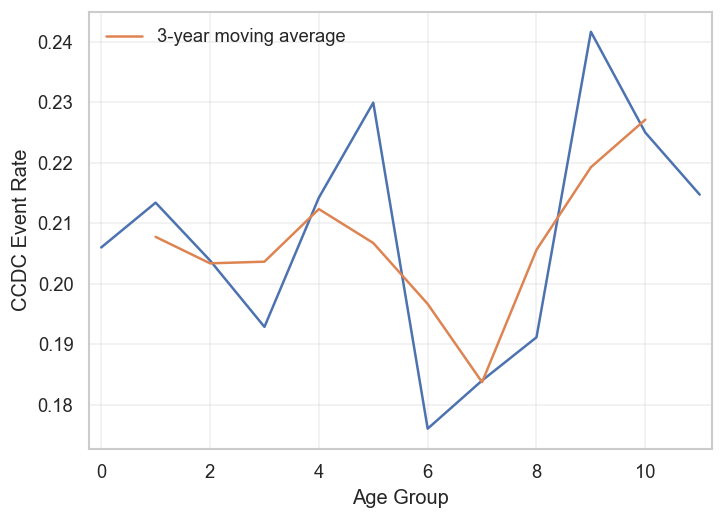

In [82]:
from matplotlib.ticker import MaxNLocator

_df = project_results_gb.copy()

_df["positive_rate_rolling_mean_3"] = (
    _df["positive_rate"].rolling(3, center=True).mean()
)

fig, ax = plt.subplots(figsize=set_size(170, 120))

ax.plot(_df.index, _df["positive_rate"])
ax.plot(_df.index, _df["positive_rate_rolling_mean_3"], label="3-year moving average")

ax.xaxis.set_major_locator(
    MaxNLocator(integer=True)
)

ax.set_xlabel("Age Group")
ax.set_ylabel("CCDC Event Rate")

ax.legend(frameon=False, loc="best")
ax.margins(x=0.02)

plt.show()

#### The Likelihood of a Repository having a CCDC Event

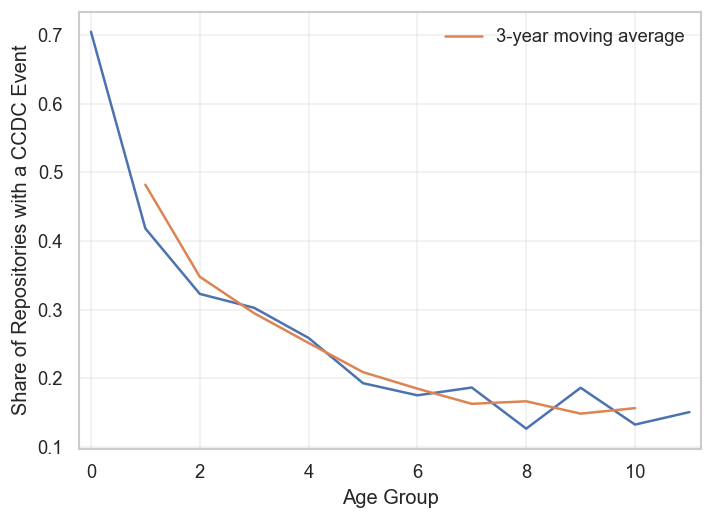

In [83]:
project_results_gb["share_pos_repos"] = (
    project_results_gb["n_pos_repos"] / project_results_gb["n_alive"]
)

_df = project_results_gb.copy()

_df["share_rolling_mean_3"] = (
    _df["share_pos_repos"].rolling(3, center=True).mean()
)

fig, ax = plt.subplots(figsize=set_size(170, 120))

ax.plot(_df.index, _df["share_pos_repos"])
ax.plot(_df.index, _df["share_rolling_mean_3"], label="3-year moving average")

ax.set_xlabel("Age Group")
ax.set_ylabel("Share of Repositories with a CCDC Event")

ax.legend(frameon=False, loc="best")
ax.margins(x=0.02)

plt.show()

#### Subject Count and CCDC Event Count

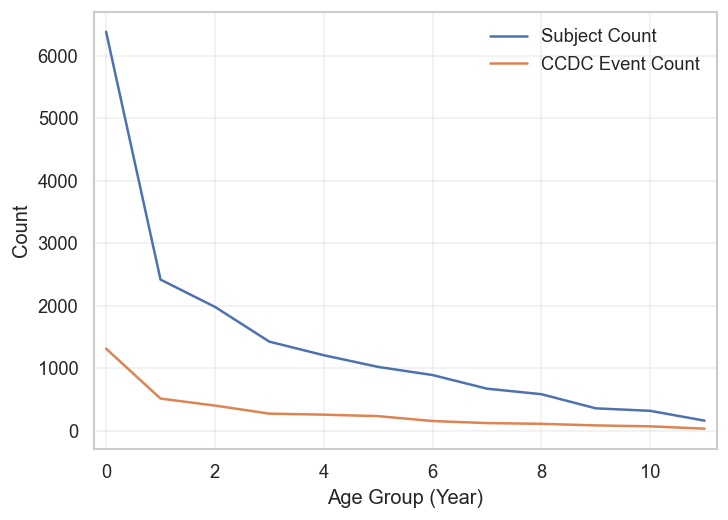

In [84]:
_df = project_results_gb.copy()

fig, ax = plt.subplots(figsize=set_size(170, 120))

ax.plot(_df.index, _df["n_subjects"], label="Subject Count")
ax.plot(_df.index, _df["n_ccdc_events"], label="CCDC Event Count")

ax.set_xlabel("Age Group (Year)")
ax.set_ylabel("Count")

ax.legend(frameon=False, loc="best")
ax.margins(x=0.02)

plt.show()

#### Channel Diversity

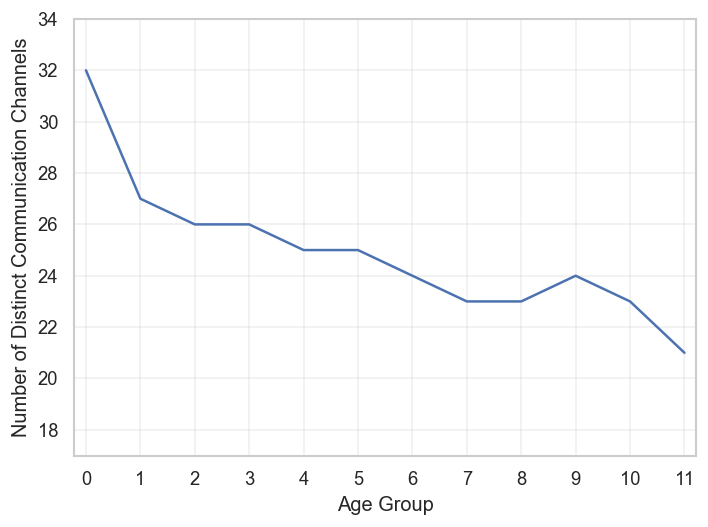

In [85]:
_df = project_results_gb.copy()

fig, ax = plt.subplots(figsize=set_size(170, 120))

ax.plot(_df.index, _df["n_distinct_channels"])

ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Distinct Communication Channels")

ax.margins(x=0.02)
ax.set_ylim(17, 34)

import matplotlib.ticker as ticker

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))

plt.show()

*Das zeigt eigentlich ziemlich deutlich, dass die Channel-Menge innerhalb eines Projektes nicht über Zeit zunimmt, sondern gleich bleibt oder abnimmt. Oder?*

#### Number Of Distinct Channels Per Positive Repository

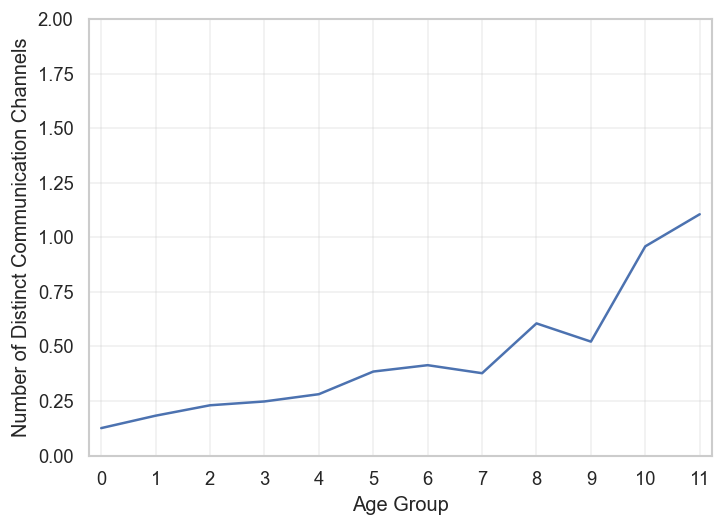

In [86]:
_df = project_results_gb.copy()

fig, ax = plt.subplots(figsize=set_size(170, 120))

ax.plot(_df.index, _df["n_channels_per_pos_repo"])

ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Distinct Communication Channels")

ax.margins(x=0.02)
ax.set_ylim(0, 2)

import matplotlib.ticker as ticker

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
# ax.yaxis.set_major_locator(ticker.MultipleLocator(2))

plt.show()

*Dadurch, dass positive Projekte schneller verschwinden, als die Channel Diversität abnimmt, kommen mehr distinct channels auf ein einzelnen positives Projekt – klar.*

#### Channels per CCDC Event

In [87]:
_ccdc_events = project_results[project_results["is_ccdc_event"] == True]

_vc_detected_channels_per_age_group = (
    _ccdc_events
    .groupby("age_group")[["detected_channels"]]
    .apply(vc_detected_channels)
)

_vc_stats_per_age_group = (
    _vc_detected_channels_per_age_group
    .reset_index()
    .groupby("age_group")["count"]
    .apply(value_counts_stats)
).unstack(fill_value=0)
_vc_stats_per_age_group = col_to_int(_vc_stats_per_age_group, INT_COLS_OF_VC_STATS)

vc_detected_channels_per_age_group = _vc_detected_channels_per_age_group.reset_index()

cc_count_per_age_group = _vc_stats_per_age_group[["total_count"]].join(
    project_results_gb["n_ccdc_events"],
    how="left",
)

cc_count_per_age_group["ratio"] = (
    cc_count_per_age_group["total_count"] / cc_count_per_age_group["n_ccdc_events"]
)

In [88]:
cc_count_per_age_group

,total_count,n_ccdc_events,ratio
age_group,,,
0,1186,1314,0.902588
1,524,516,1.015504
2,429,404,1.061881
3,303,275,1.101818
4,285,259,1.100386
5,216,235,0.919149
6,172,157,1.095541
7,163,124,1.314516
8,138,112,1.232143


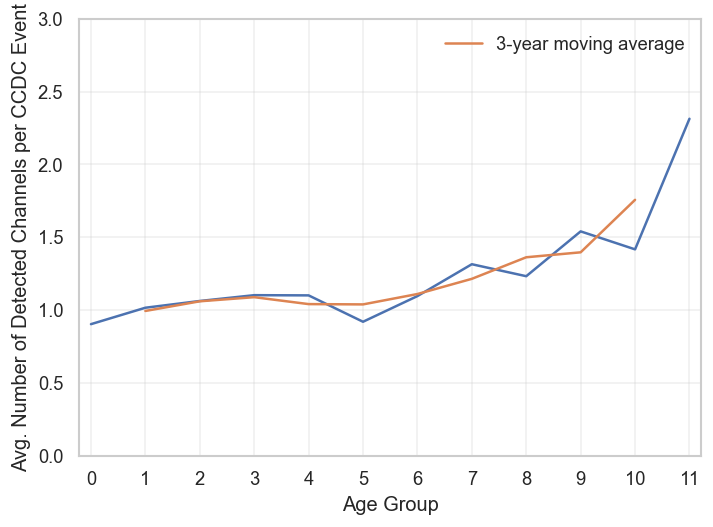

In [89]:
_df = cc_count_per_age_group.copy()

_df["ratio_rolling_mean_3"] = (
    _df["ratio"].rolling(3, center=True).mean()
)

fig, ax = plt.subplots(figsize=set_size(170, 120))

ax.plot(_df.index, _df["ratio"])
ax.plot(_df.index, _df["ratio_rolling_mean_3"], label="3-year moving average")

ax.set_xlabel("Age Group")
ax.set_ylabel("Avg. Number of Detected Channels per CCDC Event")

ax.legend(frameon=False, loc="best")
ax.margins(x=0.02)
ax.set_ylim(0, 3)

import matplotlib.ticker as ticker

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

plt.show()

#### Top 5 Channels

In [90]:
_top_5_per_age_group = (
    vc_detected_channels_per_age_group
        .sort_values(["age_group", "count"], ascending=[True, False])
        .groupby("age_group", dropna=False, sort=False)
        .head(5)
        .reset_index(drop=True)
)

How many channels have ever made it into the top 5 of an age group?

In [91]:
print(f"Answer: {_top_5_per_age_group["channel"].nunique()}")

# print(f"These are:\n{_top_5_per_age_group["channel"].unique()}")

Answer: 12


##### First Year (Age Group 0)

In [92]:
_top_5_per_age_group[_top_5_per_age_group["age_group"] == 0]

,age_group,channel,count
0,0,form,124
1,0,mail,121
2,0,issues,106
3,0,website,105
4,0,pull_request,105


##### 4th Year (Age Group 3)

In [93]:
_top_5_per_age_group[_top_5_per_age_group["age_group"] == 3]

,age_group,channel,count
15,3,pull_request,36
16,3,issues,35
17,3,mail,29
18,3,fork,29
19,3,forum,26


##### 7th Year (Age Group 8)

In [94]:
_top_5_per_age_group[_top_5_per_age_group["age_group"] == 8]

,age_group,channel,count
40,8,website,20
41,8,forum,14
42,8,pull_request,13
43,8,mail,13
44,8,form,13


##### 10th Year (Age Group 9)

In [95]:
_top_5_per_age_group[_top_5_per_age_group["age_group"] == 9]

,age_group,channel,count
45,9,form,15
46,9,forum,12
47,9,pull_request,12
48,9,issues,11
49,9,website,10
